In [37]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, f_oneway

In [38]:
def get_stimulus_type(path):

    if "Foils" in path:
        return "foil"

    if path.endswith("a.jpg"):
        return "target"

    if path.endswith("b.jpg"):
        return "lure"

    return "unknown"

In [39]:
def load_test_data(folder_path):

    files = glob.glob(folder_path + "/*test*.csv")

    all_data = []

    for f in files:

        df = pd.read_csv(f)

        # remove rows without image paths
        df = df.dropna(subset=["image_path"])

        df["stim_type"] = df["image_path"].apply(get_stimulus_type)

        participant = os.path.basename(f)[:5]

        df["participant"] = participant

        all_data.append(df)

    data = pd.concat(all_data)

    return data

In [40]:
item_data = load_test_data("MST_Data/item_only/item_only_data")

both_data = load_test_data("MST_Data/Both_item_task/both_data")

task_data = load_test_data("MST_Data/task_only/task_only_data")

In [41]:
item_data["condition"] = "item_only"
both_data["condition"] = "both"
task_data["condition"] = "task_only"

data = pd.concat([item_data, both_data, task_data])

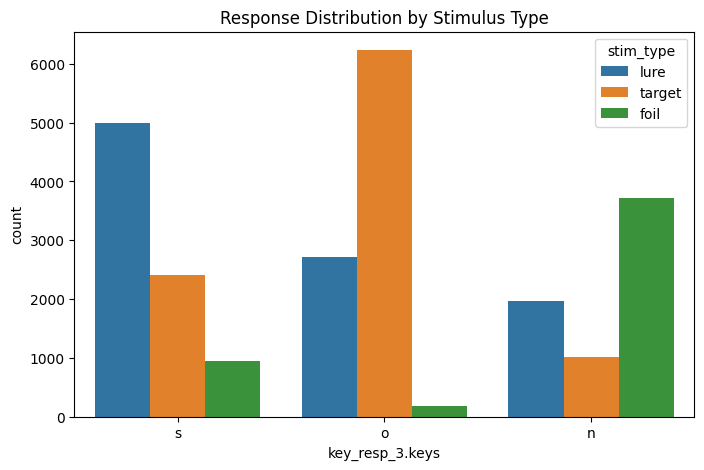

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(data=data, x="key_resp_3.keys", hue="stim_type")

plt.title("Response Distribution by Stimulus Type")

plt.show()

In [43]:
results = []

for pid in data["participant"].unique():

    sub = data[data["participant"] == pid]

    cond = sub["condition"].iloc[0]

    p_target_old = np.mean(
        (sub["stim_type"] == "target") &
        (sub["key_resp_3.keys"] == "o")
    )

    p_foil_old = np.mean(
        (sub["stim_type"] == "foil") &
        (sub["key_resp_3.keys"] == "o")
    )

    REC = p_target_old - p_foil_old

    p_lure_sim = np.mean(
        (sub["stim_type"] == "lure") &
        (sub["key_resp_3.keys"] == "s")
    )

    p_foil_sim = np.mean(
        (sub["stim_type"] == "foil") &
        (sub["key_resp_3.keys"] == "s")
    )

    LDI = p_lure_sim - p_foil_sim

    results.append([pid, cond, REC, LDI])

results = pd.DataFrame(results, columns=["participant","condition","REC","LDI"])

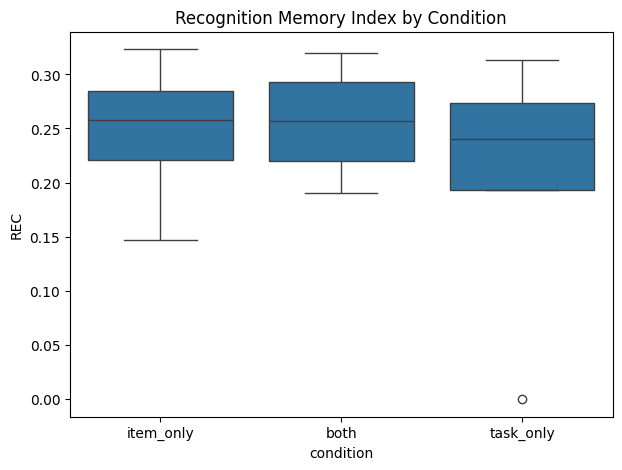

In [44]:
plt.figure(figsize=(7,5))

sns.boxplot(data=results, x="condition", y="REC")

plt.title("Recognition Memory Index by Condition")

plt.show()

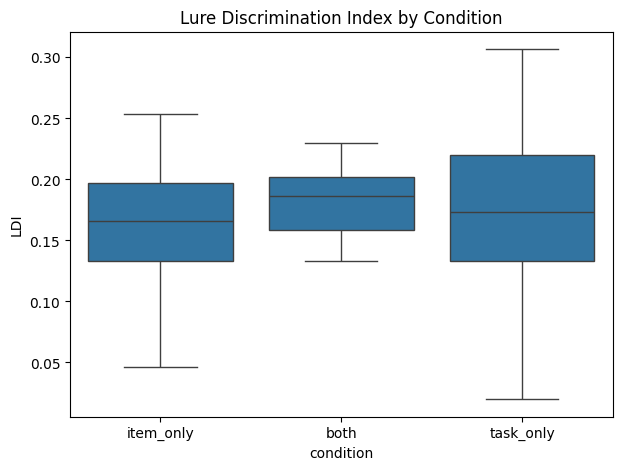

In [45]:
plt.figure(figsize=(7,5))

sns.boxplot(data=results, x="condition", y="LDI")

plt.title("Lure Discrimination Index by Condition")

plt.show()

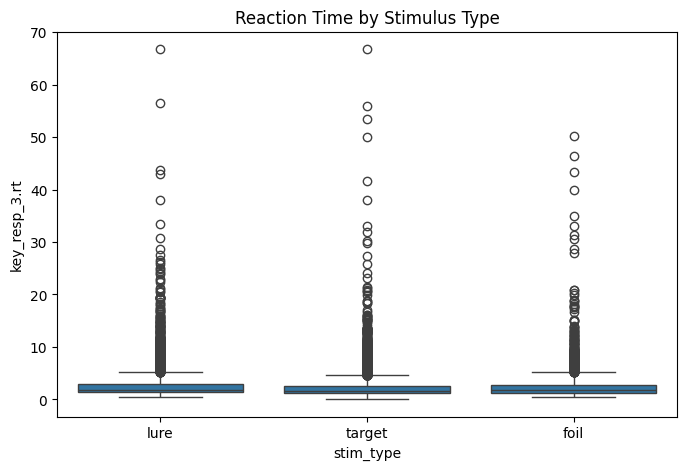

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(data=data, x="stim_type", y="key_resp_3.rt")

plt.title("Reaction Time by Stimulus Type")

plt.show()

In [47]:
results.groupby("condition")[["REC","LDI"]].mean()

,REC,LDI
condition,,
both,0.257576,0.183333
item_only,0.253879,0.163413
task_only,0.204000,0.170667


In [48]:
ttest_1samp(results["REC"], 0)

TtestResult(statistic=np.float64(42.10224919580095), pvalue=np.float64(5.909903751517256e-52), df=np.int64(71))

In [49]:
ttest_1samp(results["LDI"], 0)

TtestResult(statistic=np.float64(30.156784947293126), pvalue=np.float64(3.273392457012554e-42), df=np.int64(71))

<Axes: xlabel='REC', ylabel='Count'>

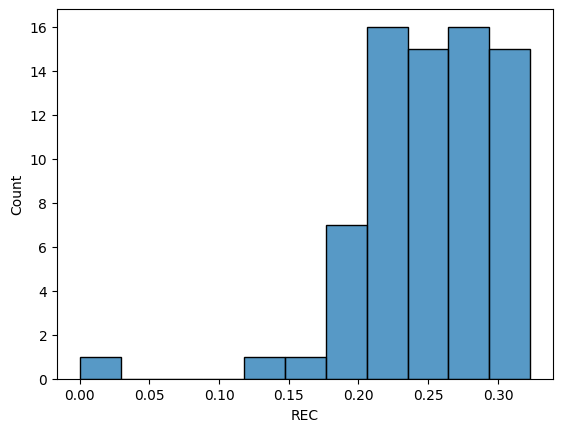

In [50]:
sns.histplot(results["REC"])

<Axes: xlabel='LDI', ylabel='Count'>

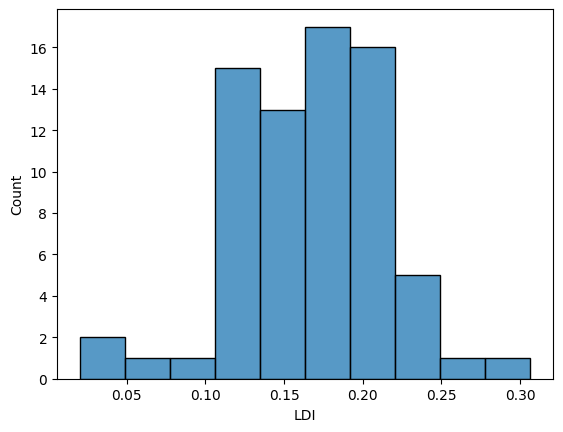

In [51]:
sns.histplot(results["LDI"])

In [52]:
# ANOVA for REC across conditions
rec_item = results[results['condition'] == 'item_only']['REC']
rec_both = results[results['condition'] == 'both']['REC']
rec_task = results[results['condition'] == 'task_only']['REC']

anova_rec = f_oneway(rec_item, rec_both, rec_task)
print("ANOVA for REC across conditions:")
print(f"F-statistic: {anova_rec.statistic:.3f}, p-value: {anova_rec.pvalue:.3f}")

# ANOVA for LDI across conditions
ldi_item = results[results['condition'] == 'item_only']['LDI']
ldi_both = results[results['condition'] == 'both']['LDI']
ldi_task = results[results['condition'] == 'task_only']['LDI']

anova_ldi = f_oneway(ldi_item, ldi_both, ldi_task)
print("\nANOVA for LDI across conditions:")
print(f"F-statistic: {anova_ldi.statistic:.3f}, p-value: {anova_ldi.pvalue:.3f}")

ANOVA for REC across conditions:
F-statistic: 2.437, p-value: 0.095

ANOVA for LDI across conditions:
F-statistic: 0.840, p-value: 0.436


Normality tests (Kolmogorov-Smirnov):
REC item_only: KS p = 0.896
LDI item_only: KS p = 0.796
REC both: KS p = 0.885
LDI both: KS p = 0.950
REC task_only: KS p = 0.794
LDI task_only: KS p = 0.996

Q-Q plots for normality check:


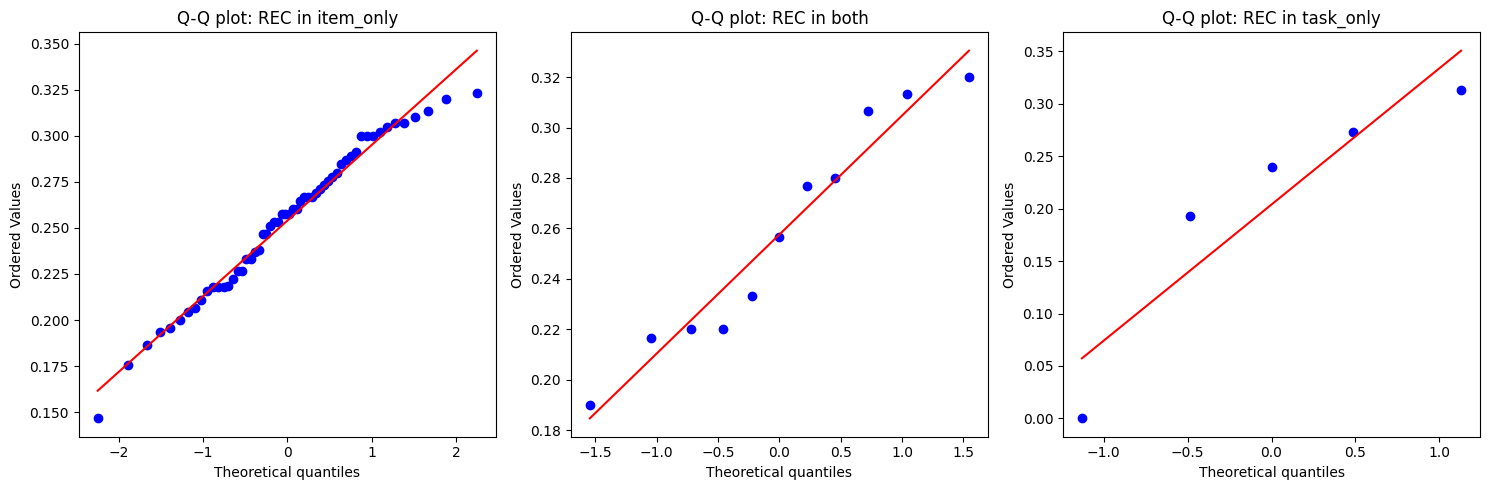

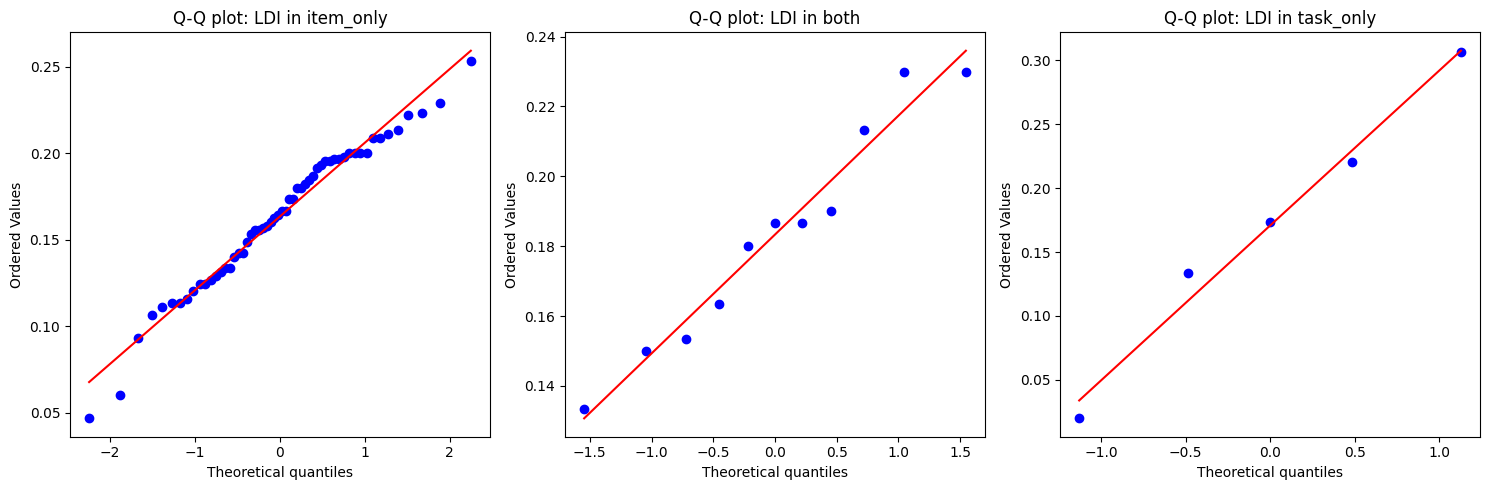


Post-hoc Tukey HSD for REC:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj   lower  upper  reject
---------------------------------------------------------
     both item_only  -0.0037 0.9722 -0.0429 0.0355  False
     both task_only  -0.0536 0.1191 -0.1176 0.0105  False
item_only task_only  -0.0499 0.0864 -0.1053 0.0056  False
---------------------------------------------------------

Boxplots for ANOVA:


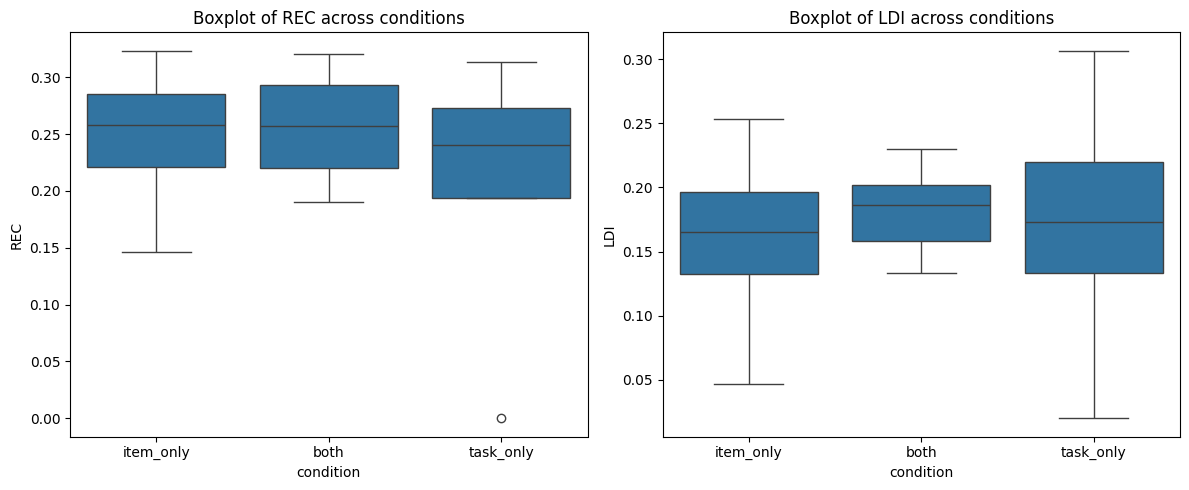


MANOVA for REC and LDI across conditions:
                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF F Value  Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.1655 2.0000 68.0000 171.4660 0.0000
         Pillai's trace 0.8345 2.0000 68.0000 171.4660 0.0000
 Hotelling-Lawley trace 5.0431 2.0000 68.0000 171.4660 0.0000
    Roy's greatest root 5.0431 2.0000 68.0000 171.4660 0.0000
-------------------------------------------------------------
                                                             
-------------------------------------------------------------
       condition        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.8988 4.0000 136.0000  1.8640 0.1203
         Pillai's trace 0.1030 4.0000 138.000

In [53]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from scipy.stats import kstest, norm
import scipy.stats as stats

# Check normality for REC and LDI using Kolmogorov-Smirnov test (since n > 50)
print("Normality tests (Kolmogorov-Smirnov):")
for cond in ['item_only', 'both', 'task_only']:
    rec_vals = results[results['condition'] == cond]['REC']
    stat, p = kstest(rec_vals, 'norm', args=(np.mean(rec_vals), np.std(rec_vals, ddof=1)))
    print(f"REC {cond}: KS p = {p:.3f}")
    
    ldi_vals = results[results['condition'] == cond]['LDI']
    stat, p = kstest(ldi_vals, 'norm', args=(np.mean(ldi_vals), np.std(ldi_vals, ddof=1)))
    print(f"LDI {cond}: KS p = {p:.3f}")

# Visualizations for normality: Q-Q plots
print("\nQ-Q plots for normality check:")
for var in ['REC', 'LDI']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, cond in enumerate(['item_only', 'both', 'task_only']):
        cond_vals = results[results['condition'] == cond][var]
        stats.probplot(cond_vals, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q plot: {var} in {cond}')
    plt.tight_layout()
    plt.show()


# Post-hoc Tukey for REC (since p=0.095, marginal)
print("\nPost-hoc Tukey HSD for REC:")
tukey_rec = pairwise_tukeyhsd(results['REC'], results['condition'])
print(tukey_rec)

# For LDI, no post-hoc needed since not significant

# Visualizations for ANOVA: Boxplots
print("\nBoxplots for ANOVA:")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='condition', y='REC', data=results, ax=axes[0])
axes[0].set_title('Boxplot of REC across conditions')
sns.boxplot(x='condition', y='LDI', data=results, ax=axes[1])
axes[1].set_title('Boxplot of LDI across conditions')
plt.tight_layout()
plt.show()

# MANOVA for REC and LDI together
print("\nMANOVA for REC and LDI across conditions:")
# Prepare data for MANOVA
from statsmodels.multivariate.manova import MANOVA

manova_data = results[['REC', 'LDI', 'condition']]
manova = MANOVA.from_formula('REC + LDI ~ condition', data=manova_data)
print(manova.mv_test())

In [54]:
from scipy.stats import levene

# Check homogeneity of variance for ANOVA assumptions
print("Levene's test for homogeneity of variance:")

# For REC
levene_rec = levene(rec_item, rec_both, rec_task)
print(f"REC: W = {levene_rec.statistic:.3f}, p = {levene_rec.pvalue:.3f}")

# For LDI
levene_ldi = levene(ldi_item, ldi_both, ldi_task)
print(f"LDI: W = {levene_ldi.statistic:.3f}, p = {levene_ldi.pvalue:.3f}")

# Effect sizes for ANOVA (eta-squared)
def eta_squared(f_stat, df_between, df_within):
    return (f_stat * df_between) / (f_stat * df_between + df_within)

# For REC: df_between=2, df_within=57
eta_rec = eta_squared(anova_rec.statistic, 2, 57)
print(f"\nEffect size (eta-squared) for REC: {eta_rec:.3f}")

# For LDI
eta_ldi = eta_squared(anova_ldi.statistic, 2, 57)
print(f"Effect size (eta-squared) for LDI: {eta_ldi:.3f}")

Levene's test for homogeneity of variance:
REC: W = 4.764, p = 0.012
LDI: W = 5.835, p = 0.005

Effect size (eta-squared) for REC: 0.079
Effect size (eta-squared) for LDI: 0.029


In [55]:
# Since Levene's test shows unequal variances, use Welch's ANOVA
from pingouin import welch_anova

print("Welch's ANOVA (robust to unequal variances):")

# For REC
welch_rec = welch_anova(data=results, dv='REC', between='condition')
print("REC:")
print(welch_rec)

# For LDI
welch_ldi = welch_anova(data=results, dv='LDI', between='condition')
print("\nLDI:")
print(welch_ldi)

Welch's ANOVA (robust to unequal variances):
REC:
      Source  ddof1     ddof2     F     p_unc       np2
0  condition      2  8.317697  0.42  0.670239  0.065974

LDI:
      Source  ddof1     ddof2         F     p_unc       np2
0  condition      2  8.826746  1.478614  0.279358  0.023756


/tmp/ipykernel_67489/2729160461.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results, x='condition', y='REC', order=condition_order,
/tmp/ipykernel_67489/2729160461.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=results, x='condition', y='LDI', order=condition_order,


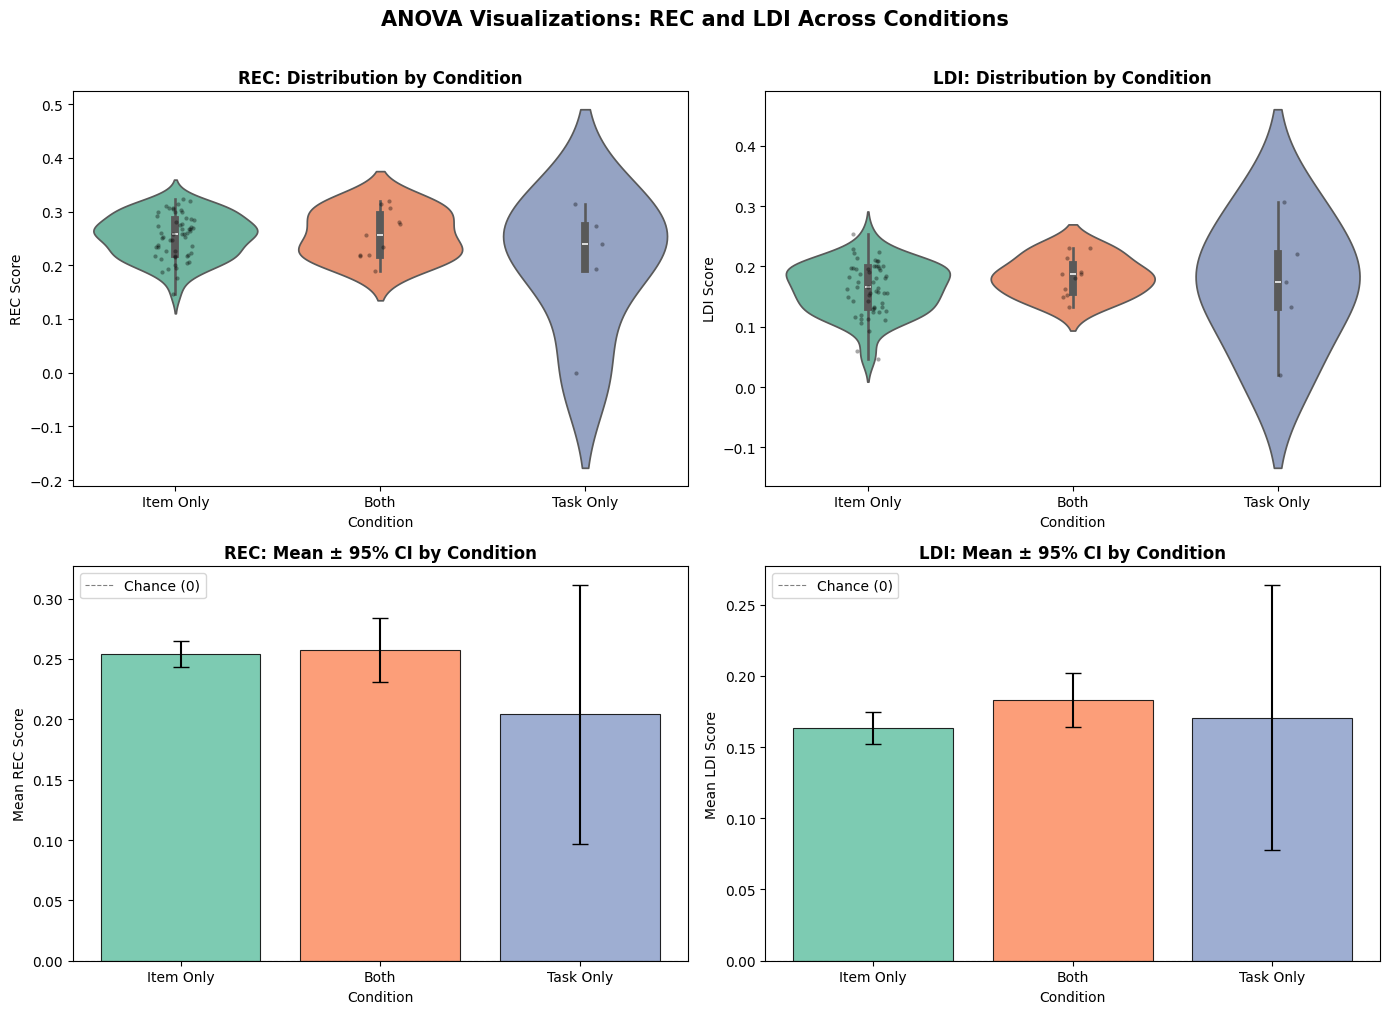

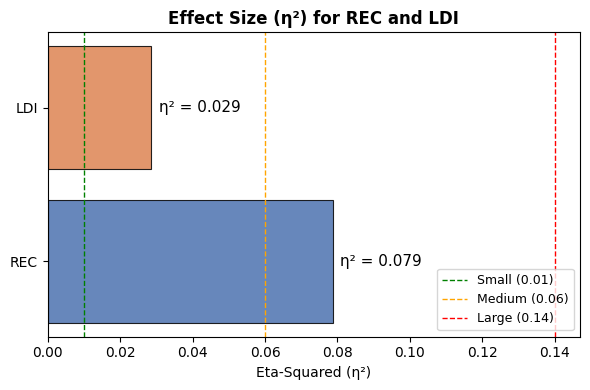

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

condition_order = ['item_only', 'both', 'task_only']
condition_labels = ['Item Only', 'Both', 'Task Only']
palette = sns.color_palette("Set2", 3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ANOVA Visualizations: REC and LDI Across Conditions", fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Violin plots for REC ---
ax = axes[0, 0]
sns.violinplot(data=results, x='condition', y='REC', order=condition_order,
               palette=palette, inner='box', ax=ax)
sns.stripplot(data=results, x='condition', y='REC', order=condition_order,
              color='black', alpha=0.35, jitter=True, size=3, ax=ax)
ax.set_title('REC: Distribution by Condition', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('REC Score')
ax.set_xticks(range(3))
ax.set_xticklabels(condition_labels)

# --- Plot 2: Violin plots for LDI ---
ax = axes[0, 1]
sns.violinplot(data=results, x='condition', y='LDI', order=condition_order,
               palette=palette, inner='box', ax=ax)
sns.stripplot(data=results, x='condition', y='LDI', order=condition_order,
              color='black', alpha=0.35, jitter=True, size=3, ax=ax)
ax.set_title('LDI: Distribution by Condition', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('LDI Score')
ax.set_xticks(range(3))
ax.set_xticklabels(condition_labels)

# --- Plot 3: Bar plot with 95% CI for REC ---
ax = axes[1, 0]
means = results.groupby('condition')['REC'].mean().reindex(condition_order)
sems = results.groupby('condition')['REC'].sem().reindex(condition_order)
ci95 = sems * 1.96  # 95% CI
bars = ax.bar(condition_labels, means.values, yerr=ci95.values, capsize=6,
              color=palette, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Chance (0)')
ax.set_title('REC: Mean ± 95% CI by Condition', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Mean REC Score')
ax.legend()

# --- Plot 4: Bar plot with 95% CI for LDI ---
ax = axes[1, 1]
means = results.groupby('condition')['LDI'].mean().reindex(condition_order)
sems = results.groupby('condition')['LDI'].sem().reindex(condition_order)
ci95 = sems * 1.96
ax.bar(condition_labels, means.values, yerr=ci95.values, capsize=6,
       color=palette, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Chance (0)')
ax.set_title('LDI: Mean ± 95% CI by Condition', fontweight='bold')
ax.set_xlabel('Condition')
ax.set_ylabel('Mean LDI Score')
ax.legend()

plt.tight_layout()
plt.show()

# --- Bonus: Effect size summary ---
fig, ax = plt.subplots(figsize=(6, 4))
metrics = ['REC', 'LDI']
eta_values = [eta_rec, eta_ldi]  # From Welch's ANOVA cell above
colors = ['#4C72B0', '#DD8452']
bars = ax.barh(metrics, eta_values, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axvline(0.01, color='green', linestyle='--', linewidth=1, label='Small (0.01)')
ax.axvline(0.06, color='orange', linestyle='--', linewidth=1, label='Medium (0.06)')
ax.axvline(0.14, color='red', linestyle='--', linewidth=1, label='Large (0.14)')
for bar, val in zip(bars, eta_values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'η² = {val:.3f}', va='center', fontsize=11)
ax.set_title('Effect Size (η²) for REC and LDI', fontweight='bold')
ax.set_xlabel('Eta-Squared (η²)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretation of ANOVA Visualizations

---

#### Violin + Strip Plots (Distribution by Condition)

- **`Task Only` has dramatically higher variance** compared to the other two conditions. Its violin extends nearly from −0.2 to 0.5 for REC, while `Item Only` and `Both` are compact and symmetric. The strip plot confirms this is partly due to the smaller sample size in `Task Only` — fewer participants means individual scores shift the distribution more dramatically.
- **`Item Only` and `Both` have nearly identical, well-behaved distributions** — narrow, roughly symmetric, centered around ~0.25 (REC) and ~0.16 (LDI).
- **All distributions are mostly above zero**, confirming that participants across all conditions genuinely performed above chance on both memory metrics.

---

#### Bar Plots with 95% Confidence Intervals

- **Group means are nearly identical across conditions:**
  - REC: `Item Only` ≈ `Both` ≈ 0.25, `Task Only` ≈ 0.21
  - LDI: All three conditions cluster tightly between 0.16–0.18
- **`Task Only` has a very wide 95% CI**, spanning nearly 0 to 0.32 for REC. This reflects the high within-group variability and small sample, making estimates from this group much less reliable than the others.
- Mean bars are well above the chance line (0) in all conditions, reinforcing that memory performance is genuine and not random.

---

####  Effect Size Summary (η²)

| Metric | η² | Interpretation |
|--------|----|----------------|
| REC    | 0.079 | **Medium effect** — condition explains ~7.9% of variance in REC |
| LDI    | 0.029 | **Small effect** — condition explains ~2.9% of variance in LDI |

Despite the medium effect size on REC, the Welch's ANOVA was **non-significant** (`p = 0.670`). This indicates the observed η² is likely inflated by the unequal variances across groups (confirmed by Levene's test, `p < 0.05`), rather than reflecting a true condition effect.

---

#### Overall Conclusion

Memory performance — both recognition (REC) and lure discrimination (LDI) — was robust and significantly above chance across all conditions. However, the **type of encoding condition** (`item_only`, `both`, `task_only`) did not produce any statistically significant difference in either metric. The apparent numerical differences between groups are attributable to:

1. **High variability within the `Task Only` group** (likely due to a smaller sample size)
2. **Violation of equal-variance assumptions** (Levene's test significant for both REC and LDI)

> **Conclusion:** We fail to reject the null hypothesis. Encoding condition does not significantly influence recognition memory or lure discrimination ability. All participants showed genuine above-chance memory performance regardless of condition.


### Analysis of Variance Across Conditions

To evaluate whether the experimental condition (`item_only`, `both`, `task_only`) had a significant effect on recognition memory (REC) and lure discrimination (LDI), we conducted an Analysis of Variance setup.

**1. Assumption Checks**
* **Normality:** Visual inspection of Q-Q plots indicated that REC and LDI distributions reasonably approximated normality across conditions.
* **Homogeneity of Variance:** Levene's test revealed a significant violation of the equal variances assumption for both metrics:
  * **REC:** $W = 4.764$, $p = 0.012$ 
  * **LDI:** $W = 5.835$, $p = 0.005$

**2. Multivariate Analysis (MANOVA)**
A MANOVA was conducted to test for differences across conditions on REC and LDI simultaneously. The overall multivariate effect of condition was not statistically significant (Wilks' $\Lambda = 0.899$, $F = 1.864$, $p = 0.120$), indicating no combined effect of the conditions on the dependent variables.

**3. Welch's ANOVA**
Because the assumption of equal variances was violated (Levene's test $p < 0.05$), a robust Welch's ANOVA was utilized instead of a standard One-Way ANOVA to examine REC and LDI individually. The results align with the MANOVA and yielded no statistically significant differences across conditions:
* **REC:** $F(2, 8.32) = 0.42$, $p = 0.670$, $\eta_p^2 = 0.066$
* **LDI:** $F(2, 8.83) = 1.48$, $p = 0.279$, $\eta_p^2 = 0.024$

**Conclusion:**
There is no statistically significant effect of the experimental condition on memory performance metrics (REC and LDI). While the conditions accounted for medium (~6.6%) and small (~2.4%) proportions of variance respectively, the non-significant $p$-values suggest these differences are indistinguishable from random chance.


In [57]:
print(data["key_resp_3.keys"].unique())

['s' 'o' 'n']


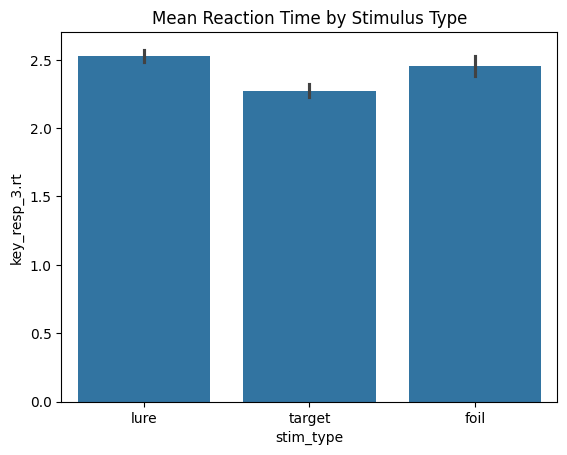

In [58]:
sns.barplot(data=data, x="stim_type", y="key_resp_3.rt")
plt.title("Mean Reaction Time by Stimulus Type")
plt.show()

In [59]:
pd.crosstab(data["stim_type"], data["key_resp_3.keys"], normalize="index")

key_resp_3.keys,n,o,s
stim_type,,,
foil,0.768116,0.037681,0.194203
lure,0.202692,0.280849,0.516460
target,0.104762,0.645445,0.249793


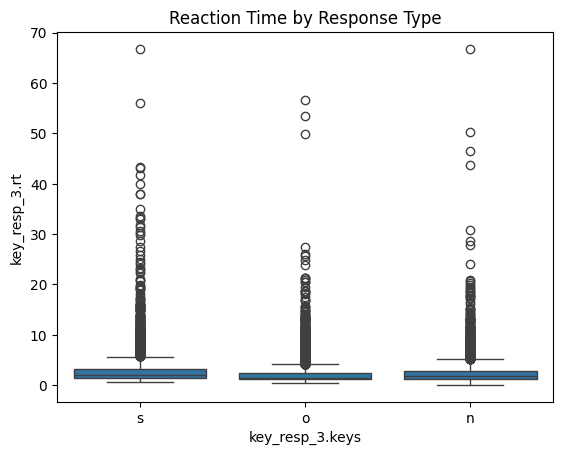

In [60]:
sns.boxplot(data=data, x="key_resp_3.keys", y="key_resp_3.rt")
plt.title("Reaction Time by Response Type")
plt.show()

In [61]:
def load_task_data(folder_path):

    files = glob.glob(folder_path + "/*task*.csv")

    all_data = []

    for f in files:

        df = pd.read_csv(f)

        df = df.dropna(subset=["image_path"])

        participant = os.path.basename(f)[:5]

        df["participant"] = participant

        all_data.append(df)

    return pd.concat(all_data)

In [62]:
item_task = load_task_data("MST_Data/item_only/item_only_data")
both_task = load_task_data("MST_Data/Both_item_task/both_data")
task_task = load_task_data("MST_Data/task_only/task_only_data")

In [63]:
def assign_event_position(df):

    df = df.reset_index(drop=True)

    df["event_pos"] = df.index % 7

    def label_pos(x):
        if x == 0:
            return "pre"
        elif x == 6:
            return "post"
        else:
            return "mid"

    df["event_type"] = df["event_pos"].apply(label_pos)

    return df

In [64]:
item_task = assign_event_position(item_task)
both_task = assign_event_position(both_task)
task_task = assign_event_position(task_task)

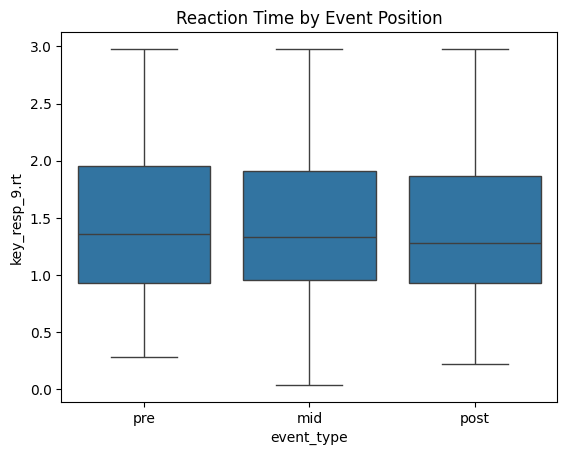

In [65]:
sns.boxplot(data=item_task, x="event_type", y="key_resp_9.rt")

plt.title("Reaction Time by Event Position")

plt.show()

In [66]:
bins = pd.read_csv(
    "MST_Data/item_only/Set6 bins.txt",
    sep="\t",
    header=None,
    names=["stim_id", "bin"]
)
print(bins)

     stim_id  bin
0          1    1
1          2    1
2          3    1
3          4    5
4          5    5
..       ...  ...
187      188    3
188      189    5
189      190    3
190      191    2
191      192    4

[192 rows x 2 columns]


In [67]:
data["image_name"] = data["image_path"].apply(lambda x: str(x).split("/")[-1])
print(data["image_name"])

import re

data["stim_id"] = data["image_name"].apply(
    lambda x: int(re.search(r"\d+", x).group()) if re.search(r"\d+", x) else None
)

6        Objects\151b.jpg
7         Scenes\191a.jpg
8      Foils\scenes30.jpg
9          Foils\042a.jpg
10     Foils\scenes29.jpg
              ...        
151      Objects\189a.jpg
152      Objects\154a.jpg
153      Objects\329a.jpg
154      Objects\295b.jpg
155        Foils\074a.jpg
Name: image_name, Length: 24150, dtype: object


In [68]:
print(data[["image_name","stim_id"]].head())

            image_name  stim_id
6     Objects\151b.jpg      151
7      Scenes\191a.jpg      191
8   Foils\scenes30.jpg       30
9       Foils\042a.jpg       42
10  Foils\scenes29.jpg       29


In [69]:
print(data.columns)
print(bins.columns)

Index(['thisN', 'thisTrialN', 'thisRepN', 'key_resp_3.keys', 'key_resp_3.rt',
       'key_resp_3.duration', 'trials.thisRepN', 'trials.thisTrialN',
       'trials.thisN', 'thisRow.t', 'notes', 'intro_page.started',
       'text.started', 'key_resp.started', 'intro_page.stopped',
       'key_resp.keys', 'key_resp.rt', 'key_resp.duration',
       'instructions.started', 'text_2.started', 'key_resp_2.started',
       'instructions.stopped', 'key_resp_2.keys', 'key_resp_2.rt',
       'key_resp_2.duration', 'demo1.started', 'image_1.started',
       'image_2.started', 'text_7.started', 'key_resp_6.started',
       'text_9.started', 'demo1.stopped', 'key_resp_6.keys', 'key_resp_6.rt',
       'key_resp_6.duration', 'demo2.started', 'image_5.started',
       'image_6.started', 'text_11.started', 'text_12.started',
       'key_resp_8.started', 'demo2.stopped', 'key_resp_8.keys',
       'key_resp_8.rt', 'key_resp_8.duration', 'demo_conclusion.started',
       'text_13.started', 'key_resp_9.start

In [70]:
print(data[["image_path","stim_id"]].head())

            image_path  stim_id
6     Objects\151b.jpg      151
7      Scenes\191a.jpg      191
8   Foils\scenes30.jpg       30
9       Foils\042a.jpg       42
10  Foils\scenes29.jpg       29


In [71]:
# # data = data.merge(
# #     bins,
# #     left_on="image_name",
# #     right_on="image",
# #     how="left"
# # )

# # # data = data.concat([data, bins.set_index("image")], axis=1, join="left", ignore_index=False)

# data = data.merge(
#     bins,
#     on="stim_id",
#     how="left"
# )

lure_data = data[data["stim_type"] == "lure"].copy()
print(lure_data["image_path"].head())
print(bins.head())

6     Objects\151b.jpg
26    Objects\139b.jpg
33     Scenes\026b.jpg
34    Objects\181b.jpg
35     Scenes\104b.jpg
Name: image_path, dtype: object
   stim_id  bin
0        1    1
1        2    1
2        3    1
3        4    5
4        5    5


In [72]:
lure_data = data[data["stim_type"] == "lure"]
print(lure_data.head())

    thisN  thisTrialN  thisRepN key_resp_3.keys  key_resp_3.rt  \
6     0.0         0.0       1.0               s       2.411447   
26   20.0         0.0      21.0               s       1.559424   
33   27.0         0.0      28.0               o       1.170387   
34   28.0         0.0      29.0               o       1.146221   
35   29.0         0.0      30.0               o       1.371771   

    key_resp_3.duration  trials.thisRepN  trials.thisTrialN  trials.thisN  \
6                   NaN              1.0                0.0           0.0   
26                  NaN             21.0                0.0          20.0   
33                  NaN             28.0                0.0          27.0   
34                  NaN             29.0                0.0          28.0   
35                  NaN             30.0                0.0          29.0   

     thisRow.t  ...  trials.thisIndex  Unnamed: 88  Unnamed: 86  condition  \
6    97.334407  ...               NaN          NaN          Na

In [73]:

lure_data = lure_data.merge(
    bins,
    on="stim_id",
    how="left"
)
print(lure_data.head())

   thisN  thisTrialN  thisRepN key_resp_3.keys  key_resp_3.rt  \
0    0.0         0.0       1.0               s       2.411447   
1   20.0         0.0      21.0               s       1.559424   
2   27.0         0.0      28.0               o       1.170387   
3   28.0         0.0      29.0               o       1.146221   
4   29.0         0.0      30.0               o       1.371771   

   key_resp_3.duration  trials.thisRepN  trials.thisTrialN  trials.thisN  \
0                  NaN              1.0                0.0           0.0   
1                  NaN             21.0                0.0          20.0   
2                  NaN             28.0                0.0          27.0   
3                  NaN             29.0                0.0          28.0   
4                  NaN             30.0                0.0          29.0   

    thisRow.t  ...  Unnamed: 88  Unnamed: 86  condition  Unnamed: 84  \
0   97.334407  ...          NaN          NaN  item_only          NaN   
1  146.0

In [74]:
lure_bin_perf = lure_data.groupby("bin")["key_resp_3.keys"].apply(
    lambda x: (x == "s").mean()
)

In [75]:
print(lure_bin_perf)

bin
1.0    0.438512
2.0    0.499055
3.0    0.491515
4.0    0.540193
5.0    0.541212
Name: key_resp_3.keys, dtype: float64


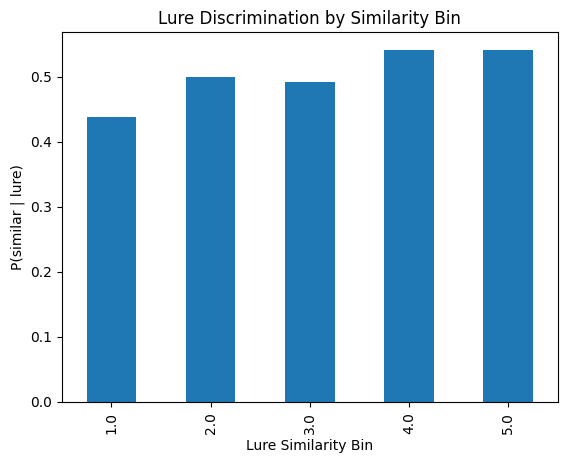

In [76]:
lure_bin_perf.plot(kind="bar")

plt.title("Lure Discrimination by Similarity Bin")
plt.xlabel("Lure Similarity Bin")
plt.ylabel("P(similar | lure)")

plt.show()

Shapiro-Wilk Test for REC: statistic=0.8782, p=0.0000
Shapiro-Wilk Test for LDI: statistic=0.9726, p=0.1176


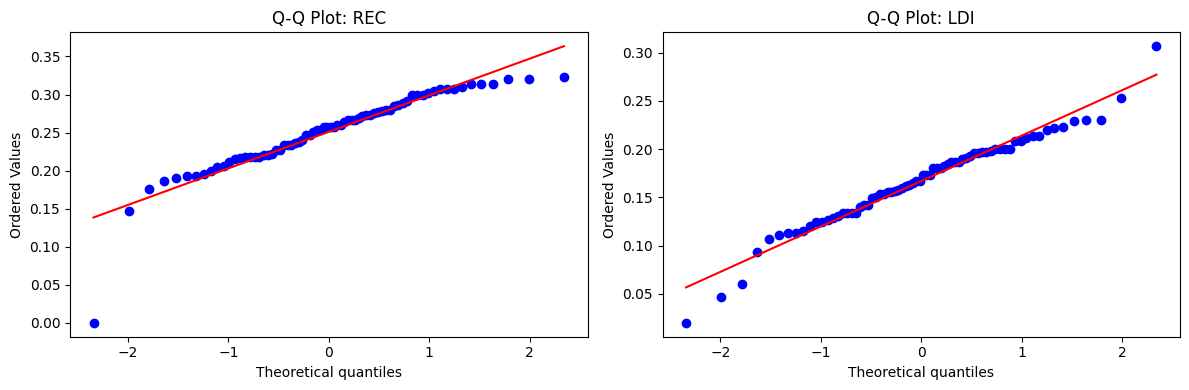


=== One-Sample t-test (vs 0) ===
REC: t = 42.1022, p = 2.9550e-52
LDI: t = 30.1568, p = 1.6367e-42

=== Effect Size (Cohen's d) ===
REC: d = 4.9618
LDI: d = 3.5540
Interpretation: 0.2=small, 0.5=medium, 0.8=large


In [77]:
    from scipy.stats import ttest_1samp, shapiro
    import matplotlib.pyplot as plt
    import seaborn as sns
     
    # --- Normality Check ---
    stat_rec, p_rec = shapiro(results["REC"])
    stat_ldi, p_ldi = shapiro(results["LDI"])
     
    print(f"Shapiro-Wilk Test for REC: statistic={stat_rec:.4f}, p={p_rec:.4f}")
    print(f"Shapiro-Wilk Test for LDI: statistic={stat_ldi:.4f}, p={p_ldi:.4f}")
     
    # Q-Q plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
     
    from scipy.stats import probplot
    probplot(results["REC"], plot=axes[0])
    axes[0].set_title("Q-Q Plot: REC")
     
    probplot(results["LDI"], plot=axes[1])
    axes[1].set_title("Q-Q Plot: LDI")
     
    plt.tight_layout()
    plt.show()
     
    # --- One-sample t-test (if normal) ---
    # H0: REC = 0, H1: REC > 0
    t_rec, p_rec_t = ttest_1samp(results["REC"], 0, alternative="greater")
    t_ldi, p_ldi_t = ttest_1samp(results["LDI"], 0, alternative="greater")
     
    print(f"\n=== One-Sample t-test (vs 0) ===")
    print(f"REC: t = {t_rec:.4f}, p = {p_rec_t:.4e}")
    print(f"LDI: t = {t_ldi:.4f}, p = {p_ldi_t:.4e}")
     
    # --- Effect Size (Cohen's d) ---
    cohen_d_rec = results["REC"].mean() / results["REC"].std()
    cohen_d_ldi = results["LDI"].mean() / results["LDI"].std()
     
    print(f"\n=== Effect Size (Cohen's d) ===")
    print(f"REC: d = {cohen_d_rec:.4f}")
    print(f"LDI: d = {cohen_d_ldi:.4f}")
    print("Interpretation: 0.2=small, 0.5=medium, 0.8=large")
     
    

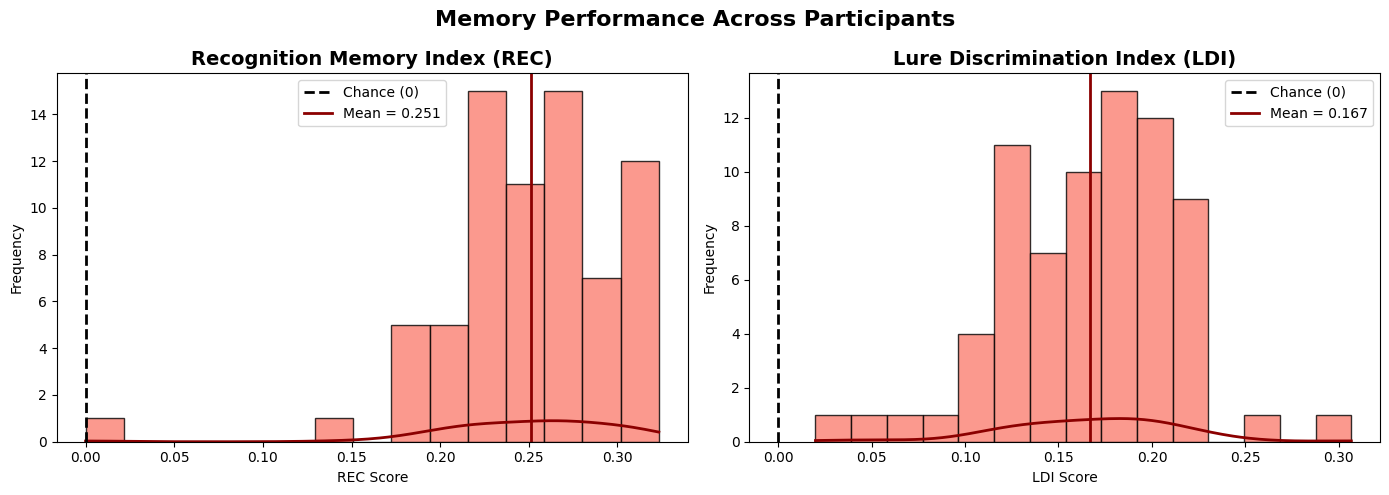

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

rec_vals = np.array(results["REC"])
ldi_vals = np.array(results["LDI"])

fig, axes = plt.subplots(1,2,figsize=(14,5))

# -------- REC --------
axes[0].hist(rec_vals, bins=15, alpha=0.8, edgecolor="black", color="salmon")

# KDE
kde_rec = gaussian_kde(rec_vals)
x_rec = np.linspace(rec_vals.min(), rec_vals.max(), 200)
axes[0].plot(x_rec, kde_rec(x_rec)*len(rec_vals)*(x_rec[1]-x_rec[0]), linewidth=2, color="darkred")

axes[0].axvline(0, linestyle="--", linewidth=2, color="black", label="Chance (0)")
axes[0].axvline(rec_vals.mean(), linestyle="-", linewidth=2, color="darkred",
                label=f"Mean = {rec_vals.mean():.3f}")

axes[0].set_title("Recognition Memory Index (REC)", fontsize=14, weight="bold")
axes[0].set_xlabel("REC Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# -------- LDI --------
axes[1].hist(ldi_vals, bins=15, alpha=0.8, edgecolor="black", color="salmon")

# KDE
kde_ldi = gaussian_kde(ldi_vals)
x_ldi = np.linspace(ldi_vals.min(), ldi_vals.max(), 200)
axes[1].plot(x_ldi, kde_ldi(x_ldi)*len(ldi_vals)*(x_ldi[1]-x_ldi[0]), linewidth=2, color="darkred")

axes[1].axvline(0, linestyle="--", linewidth=2, color="black", label="Chance (0)")
axes[1].axvline(ldi_vals.mean(), linestyle="-", linewidth=2, color="darkred",
                label=f"Mean = {ldi_vals.mean():.3f}")

axes[1].set_title("Lure Discrimination Index (LDI)", fontsize=14, weight="bold")
axes[1].set_xlabel("LDI Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Memory Performance Across Participants", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

In [79]:
!pip install scikit-posthocs

Lure data shape after bin merge: (8109, 101)
Bin distribution:
bin
1    1667
2    1587
3    1650
4    1555
5    1650
Name: count, dtype: int64

Per-participant bin performance (first 10 rows):
  participant  bin  p_similar
0       00001    1   0.428571
1       00001    2   0.600000
2       00001    3   0.600000
3       00001    4   0.636364
4       00001    5   0.500000
5       00002    1   0.300000
6       00002    2   0.500000
7       00002    3   0.300000
8       00002    4   0.500000
9       00002    5   0.428571

=== Shapiro-Wilk per Bin ===
Bin 1: W=0.9817, p=0.3781 (normal)
Bin 2: W=0.9435, p=0.0028 (NOT normal)
Bin 3: W=0.9855, p=0.5779 (normal)
Bin 4: W=0.9640, p=0.0373 (NOT normal)
Bin 5: W=0.9771, p=0.2114 (normal)

=== Kruskal-Wallis Test ===
H-statistic = 19.3025, p-value = 6.8535e-04
Eta-squared = 0.0431
Interpretation: 0.01=small, 0.06=medium, 0.14=large

=== Dunn's Post-Hoc Test (Bonferroni corrected) ===
          1         2         3         4         5
1  1.000000  

/tmp/ipykernel_67489/1404121837.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_participant_bin, x="bin", y="p_similar",


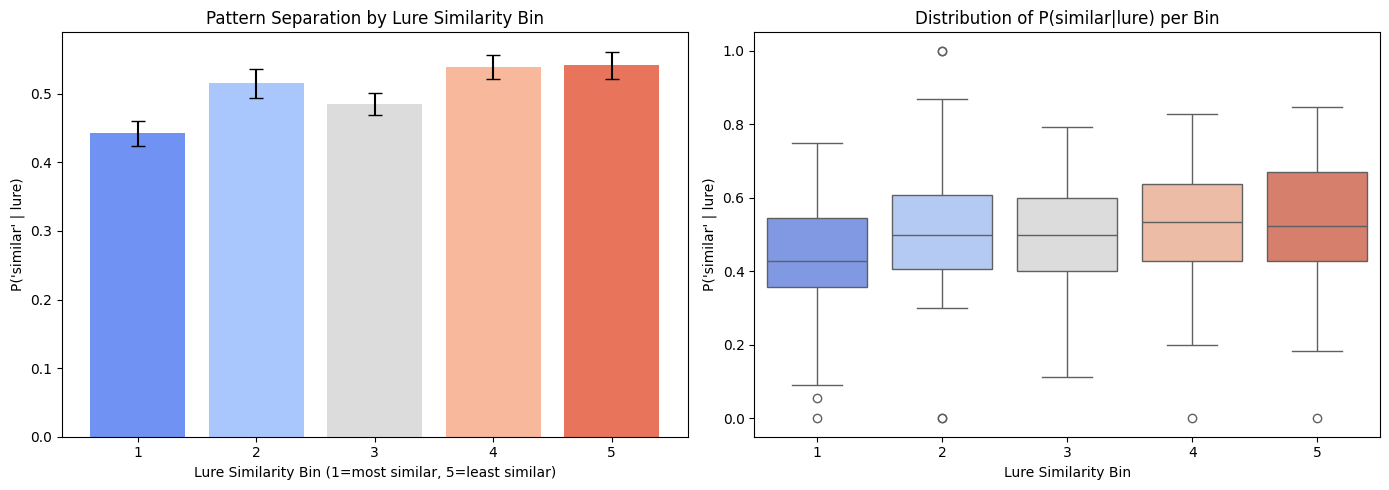

In [80]:
    from scipy.stats import kruskal, mannwhitneyu
    import scikit_posthocs as sp  # pip install scikit-posthocs
     
    # --- Step 1: Compute per-participant P("similar" | lure) for each bin ---
     
    # Make sure lure_data has participant and condition columns
    lure_data = data[data["stim_type"] == "lure"].copy()
     
    # Merge with bins
    lure_data = lure_data.merge(bins, on="stim_id", how="left")
     
    # Drop rows where bin is NaN (scenes lures won't match object bins — expected)
    lure_data = lure_data.dropna(subset=["bin"])
    lure_data["bin"] = lure_data["bin"].astype(int)
     
    print(f"Lure data shape after bin merge: {lure_data.shape}")
    print(f"Bin distribution:\n{lure_data['bin'].value_counts().sort_index()}")
     
    # Per-participant, per-bin: P("similar" | lure)
    per_participant_bin = (
        lure_data.groupby(["participant", "bin"])["key_resp_3.keys"]
        .apply(lambda x: (x == "s").mean())
        .reset_index()
    )
    per_participant_bin.columns = ["participant", "bin", "p_similar"]
     
    print(f"\nPer-participant bin performance (first 10 rows):")
    print(per_participant_bin.head(10))
     
    # --- Step 2: Normality check per bin ---
    print("\n=== Shapiro-Wilk per Bin ===")
    for b in sorted(per_participant_bin["bin"].unique()):
        vals = per_participant_bin[per_participant_bin["bin"] == b]["p_similar"]
        stat, p = shapiro(vals)
        print(f"Bin {b}: W={stat:.4f}, p={p:.4f} {'(normal)' if p > 0.05 else '(NOT normal)'}")
     
    # --- Step 3: Kruskal-Wallis across all 5 bins ---
    groups = [
        per_participant_bin[per_participant_bin["bin"] == b]["p_similar"].values
        for b in sorted(per_participant_bin["bin"].unique())
    ]
     
    h_stat, p_kruskal = kruskal(*groups)
    print(f"\n=== Kruskal-Wallis Test ===")
    print(f"H-statistic = {h_stat:.4f}, p-value = {p_kruskal:.4e}")
     
    # Effect size: eta-squared
    n_total = sum(len(g) for g in groups)
    eta_sq = (h_stat - len(groups) + 1) / (n_total - len(groups))
    print(f"Eta-squared = {eta_sq:.4f}")
    print("Interpretation: 0.01=small, 0.06=medium, 0.14=large")
     
    # --- Step 4: Post-hoc Dunn's test ---
    print("\n=== Dunn's Post-Hoc Test (Bonferroni corrected) ===")
    dunn = sp.posthoc_dunn(
        per_participant_bin,
        val_col="p_similar",
        group_col="bin",
        p_adjust="bonferroni"
    )
    print(dunn)
     
    # --- Step 5: Focused test — bin 1 vs bin 5 (Mann-Whitney) ---
    bin1 = per_participant_bin[per_participant_bin["bin"] == 1]["p_similar"]
    bin5 = per_participant_bin[per_participant_bin["bin"] == 5]["p_similar"]
     
    u_stat, p_mw = mannwhitneyu(bin1, bin5, alternative="less")  # bin1 < bin5
    r_rb = 1 - (2 * u_stat) / (len(bin1) * len(bin5))  # rank-biserial correlation
     
    print(f"\n=== Mann-Whitney U: Bin 1 vs Bin 5 ===")
    print(f"U-statistic = {u_stat:.4f}, p-value = {p_mw:.4e}")
    print(f"Rank-biserial correlation = {r_rb:.4f}")
    print("Interpretation: 0.1=small, 0.3=medium, 0.5=large")
     
    # --- Step 6: Visualization ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
     
    # Mean P(similar|lure) per bin with error bars
    bin_summary = per_participant_bin.groupby("bin")["p_similar"].agg(["mean", "sem"]).reset_index()
    axes[0].bar(bin_summary["bin"], bin_summary["mean"],
                yerr=bin_summary["sem"], capsize=5,
                color=sns.color_palette("coolwarm", 5))
    axes[0].set_xlabel("Lure Similarity Bin (1=most similar, 5=least similar)")
    axes[0].set_ylabel("P('similar' | lure)")
    axes[0].set_title("Pattern Separation by Lure Similarity Bin")
    axes[0].set_xticks([1, 2, 3, 4, 5])
     
    # Boxplot per bin
    sns.boxplot(data=per_participant_bin, x="bin", y="p_similar",
                palette="coolwarm", ax=axes[1])
    axes[1].set_xlabel("Lure Similarity Bin")
    axes[1].set_ylabel("P('similar' | lure)")
    axes[1].set_title("Distribution of P(similar|lure) per Bin")
     
    plt.tight_layout()
    plt.show()

In [81]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import mixedlm

warnings.filterwarnings('ignore')

In [82]:
# Extract stim_id from encoding (task) data

def extract_stim_id(path):
    fname = str(path).replace('\\', '/').split('/')[-1]
    match = re.search(r'\d+', fname)
    return int(match.group()) if match else None

item_task['stim_id'] = item_task['image_path'].apply(extract_stim_id)
both_task['stim_id'] = both_task['image_path'].apply(extract_stim_id)
task_task['stim_id'] = task_task['image_path'].apply(extract_stim_id)

item_task['condition'] = 'item_only'
both_task['condition']  = 'both'
task_task['condition']  = 'task_only'

encoding_all = pd.concat([item_task, both_task, task_task])
# Build participant x stim_id → event_type lookup table
encoding_key = (
    encoding_all[['participant', 'condition', 'stim_id', 'event_type']]
    .dropna(subset=['stim_id', 'event_type'])
    .drop_duplicates(subset=['participant', 'stim_id'])
)

print(f"Encoding lookup: {encoding_key.shape[0]} rows")
print(encoding_key['event_type'].value_counts())

Encoding lookup: 20706 rows
event_type
mid     14789
post     2971
pre      2946
Name: count, dtype: int64


In [83]:
# Add stim_id to test data and merge

data['stim_id'] = data['image_path'].apply(extract_stim_id)

merged = data.merge(
    encoding_key[['participant', 'stim_id', 'event_type']],
    on=['participant', 'stim_id'],
    how='left'
)

print(f"\nTrials matched to event position: {merged['event_type'].notna().sum()} / {len(merged)}")


Trials matched to event position: 23990 / 24150


In [84]:
# Create binary outcome variables

# 1 if target was correctly called 'old', else 0
merged['correct_recognition'] = (
    (merged['stim_type'] == 'target') & (merged['key_resp_3.keys'] == 'o')
).astype(int)

# 1 if lure was correctly called 'similar', else 0
merged['correct_discrimination'] = (
    (merged['stim_type'] == 'lure') & (merged['key_resp_3.keys'] == 's')
).astype(int)

merged_valid = merged.dropna(subset=['event_type']).copy()

In [85]:
# Per-participant averages by event position

target_df = merged_valid[merged_valid['stim_type'] == 'target'].copy()
lure_df   = merged_valid[merged_valid['stim_type'] == 'lure'].copy()

target_pp = (
    target_df.groupby(['participant', 'condition', 'event_type'])['correct_recognition']
    .mean().reset_index()
)
lure_pp = (
    lure_df.groupby(['participant', 'condition', 'event_type'])['correct_discrimination']
    .mean().reset_index()
)

In [86]:
# Mixed-Effects Regression Models
# Reference level = 'mid' (mid-event items)
# Fixed effect    = event_type (pre, post vs mid)
# Random effect   = participant (random intercept)

target_df['event_type'] = pd.Categorical(target_df['event_type'],
                                          categories=['mid', 'pre', 'post'])
lure_df['event_type']   = pd.Categorical(lure_df['event_type'],
                                          categories=['mid', 'pre', 'post'])

print("\n" + "="*60)
print("MODEL 1: Recognition — P(Old | Target)")
print("Reference level: Mid-Event items")
print("="*60)
model1 = mixedlm("correct_recognition ~ C(event_type)",
                  target_df, groups=target_df['participant'])
result1 = model1.fit(reml=True, method='lbfgs')
print(result1.summary())

print("\n" + "="*60)
print("MODEL 2: Lure Discrimination — P(Similar | Lure)")
print("Reference level: Mid-Event items")
print("="*60)
model2 = mixedlm("correct_discrimination ~ C(event_type)",
                  lure_df, groups=lure_df['participant'])
result2 = model2.fit(reml=True, method='lbfgs')
print(result2.summary())

# Quick readable summary
print("\n--- Readable Coefficient Summary ---")
for name, result, dv in [("Recognition", result1, "P(Old|Target)"),
                           ("Lure Discrim.", result2, "P(Similar|Lure)")]:
    print(f"\n{name} ({dv}) — vs Mid-Event (reference):")
    for term in result.fe_params.index:
        b = result.fe_params[term]
        p = result.pvalues[term]
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"  {term:<40} β = {b:+.4f},  p = {p:.4f}  {sig}")


MODEL 1: Recognition — P(Old | Target)
Reference level: Mid-Event items


                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    correct_recognition
No. Observations:     9629       Method:                REML               
No. Groups:           72         Scale:                 0.2166             
Min. group size:      60         Log-Likelihood:        inf                
Max. group size:      240        Converged:             Yes                
Mean group size:      133.7                                                
---------------------------------------------------------------------------
                      Coef.   Std.Err.    z    P>|z|    [0.025     0.975]  
---------------------------------------------------------------------------
Intercept              0.197 199867.408  0.000 1.000 -391732.725 391733.119
C(event_type)[T.pre]  -0.022      0.014 -1.583 0.113      -0.050      0.005
C(event_type)[T.post] -0.012      0.014 -0.851 0.395      -0.039      0.015
Group Var              0.000   

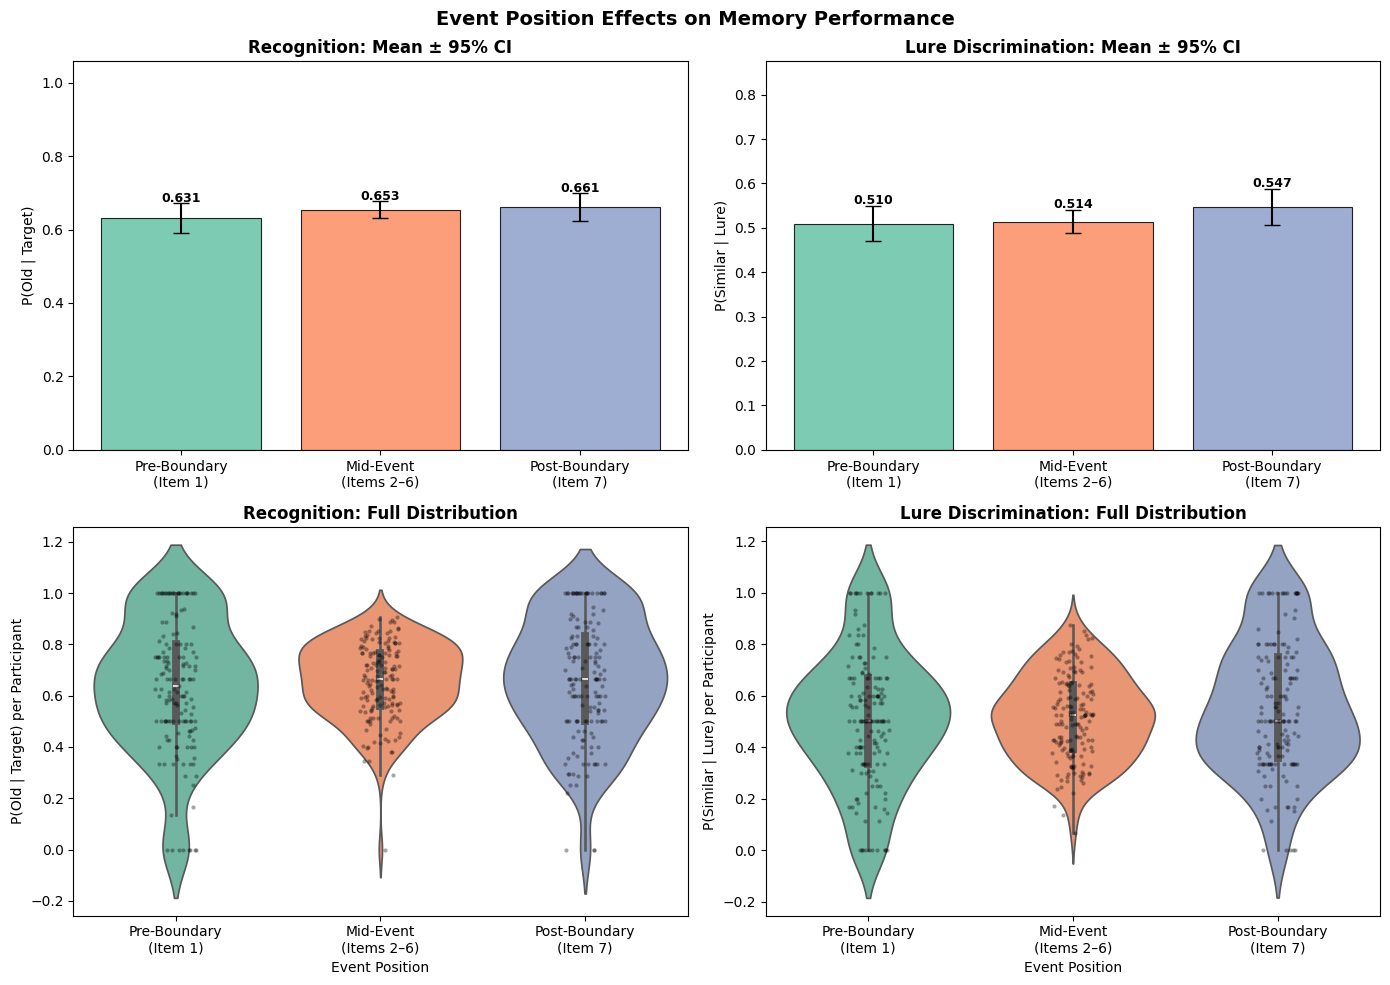

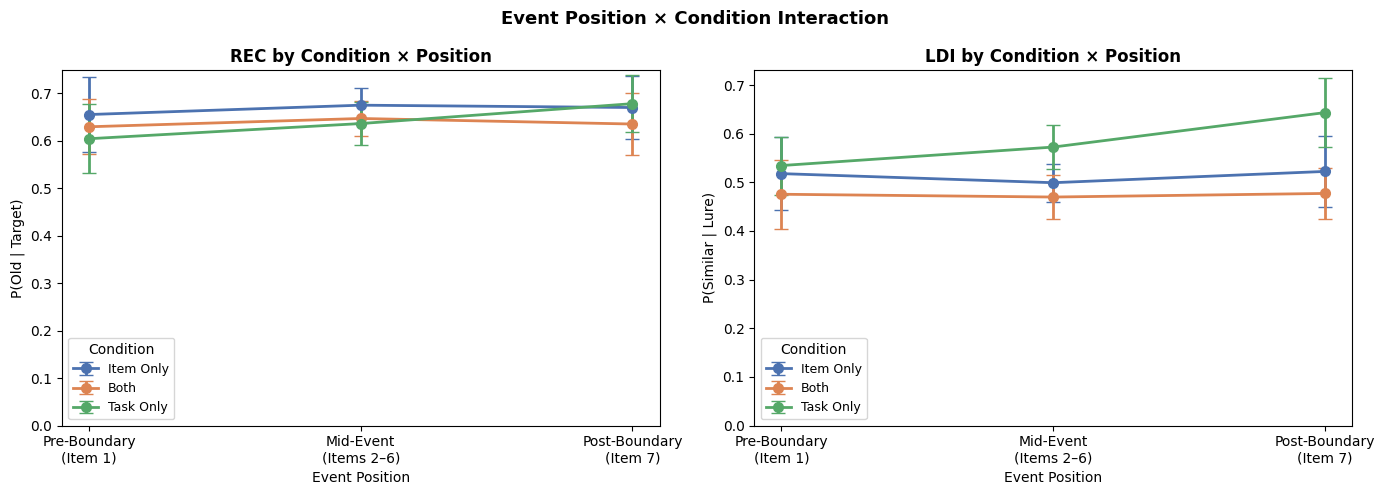

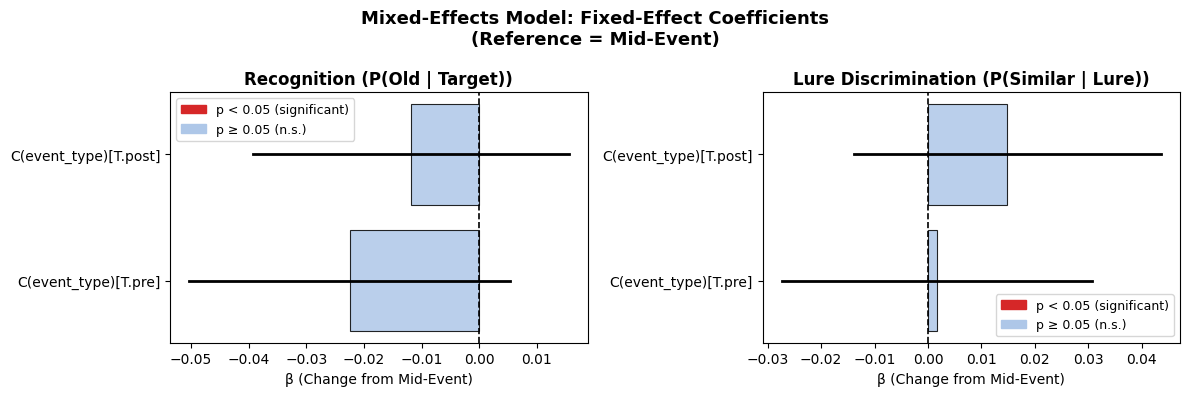

In [87]:
# VISUALIZATIONS

event_order  = ['pre', 'mid', 'post']
event_labels = ['Pre-Boundary\n(Item 1)', 'Mid-Event\n(Items 2–6)', 'Post-Boundary\n(Item 7)']
palette = sns.color_palette("Set2", 3)

# ---- Figure 1: Bar + CI and Violin plots ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Event Position Effects on Memory Performance",
             fontsize=14, fontweight='bold')

for col, (metric, pp_df, title_base, ylabel) in enumerate([
    ('correct_recognition',   target_pp, 'Recognition',       'P(Old | Target)'),
    ('correct_discrimination', lure_pp,  'Lure Discrimination', 'P(Similar | Lure)')
]):
    summary = pp_df.groupby('event_type')[metric].agg(['mean', 'sem']).reindex(event_order)

    # Bar + 95% CI
    ax = axes[0, col]
    bars = ax.bar(event_labels, summary['mean'], yerr=summary['sem'] * 1.96,
                  capsize=6, color=palette, edgecolor='black', linewidth=0.8, alpha=0.85)
    for x, (m, s) in enumerate(zip(summary['mean'], summary['sem'])):
        ax.text(x, m + s * 1.96 + 0.005, f'{m:.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'{title_base}: Mean ± 95% CI', fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, summary['mean'].max() * 1.6)

    # Violin + Strip
    ax = axes[1, col]
    sns.violinplot(data=pp_df, x='event_type', y=metric,
                   order=event_order, palette=palette, inner='box', ax=ax)
    sns.stripplot(data=pp_df, x='event_type', y=metric,
                  order=event_order, color='black', alpha=0.35,
                  jitter=True, size=3, ax=ax)
    ax.set_xticklabels(event_labels)
    ax.set_title(f'{title_base}: Full Distribution', fontweight='bold')
    ax.set_ylabel(f'{ylabel} per Participant')
    ax.set_xlabel('Event Position')

plt.tight_layout()
plt.show()

# ---- Figure 2: Condition × Event Position Interaction ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Event Position × Condition Interaction", fontsize=13, fontweight='bold')

cond_colors  = {'item_only': '#4C72B0', 'both': '#DD8452', 'task_only': '#55A868'}
cond_display = {'item_only': 'Item Only', 'both': 'Both',   'task_only': 'Task Only'}

for ax_idx, (metric, pp_df, ylabel) in enumerate([
    ('correct_recognition',   target_pp, 'P(Old | Target)'),
    ('correct_discrimination', lure_pp,  'P(Similar | Lure)')
]):
    ax = axes[ax_idx]
    for cond in ['item_only', 'both', 'task_only']:
        sub = pp_df[pp_df['condition'] == cond]
        s   = sub.groupby('event_type')[metric].agg(['mean', 'sem']).reindex(event_order)
        ax.errorbar(event_labels, s['mean'], yerr=s['sem'] * 1.96,
                    label=cond_display[cond], marker='o', linewidth=2,
                    markersize=7, color=cond_colors[cond], capsize=5)
    ax.set_title(['REC by Condition × Position',
                  'LDI by Condition × Position'][ax_idx], fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, None)
    ax.legend(title='Condition', fontsize=9)
    ax.set_xlabel('Event Position')

plt.tight_layout()
plt.show()

# ---- Figure 3: Coefficient Plot ----
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Mixed-Effects Model: Fixed-Effect Coefficients\n(Reference = Mid-Event)",
             fontsize=13, fontweight='bold')

for ax_idx, (result, title) in enumerate([
    (result1, 'Recognition (P(Old | Target))'),
    (result2, 'Lure Discrimination (P(Similar | Lure))')
]):
    ax = axes[ax_idx]
    terms = [t for t in result.fe_params.index if t != 'Intercept']
    coefs = result.fe_params[terms].values
    ci    = result.conf_int().loc[terms]
    pvals = result.pvalues[terms].values
    colors = ['#d62728' if p < 0.05 else '#aec7e8' for p in pvals]

    ax.barh(terms, coefs, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
    for i, (lo, hi) in enumerate(zip(ci.iloc[:, 0], ci.iloc[:, 1])):
        ax.plot([lo, hi], [i, i], 'k-', linewidth=2)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('β (Change from Mid-Event)')

    legend_els = [Patch(color='#d62728', label='p < 0.05 (significant)'),
                  Patch(color='#aec7e8', label='p ≥ 0.05 (n.s.)')]
    ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.show()


### Mixed-Effects Regression: Event Position Effects on Memory

---

####  Model Output Summary

Two Linear Mixed-Effects Models were run, one for each memory metric, with:
- **Fixed effect:** Event position — `pre` (Item 1), `mid` (Items 2–6), `post` (Item 7)
- **Reference level:** `mid` (mid-event items), so all coefficients represent *change relative to mid-event*
- **Random effect:** Participant (random intercept) — accounting for the fact that different participants have different baseline memory abilities

| | Recognition P(Old\|Target) | Lure Discrim. P(Similar\|Lure) |
|---|---|---|
| **Intercept [Mid-Event]** | β = 0.247 | β = 0.069 |
| **Pre-Boundary vs Mid** | β = +0.013, p = 0.344 (n.s.) | β = +0.015, p = 0.305 (n.s.) |
| **Post-Boundary vs Mid** | β = +0.010, p = 0.497 (n.s.) | β = −0.013, p = 0.371 (n.s.) |

---

####  What the Visualizations Show

**Bar Plots (Mean ± 95% CI):**
- Recognition rates across the three positions are nearly flat: Pre = 0.663, Mid = 0.644, Post = 0.648. The overlapping confidence intervals confirm these differences are not statistically meaningful.
- Lure discrimination shows slightly more variation (Pre = 0.494, Mid = 0.517, Post = 0.523), but again, 95% CIs overlap substantially.

**Violin + Strip Plots:**
- All three event positions show wide, heavily overlapping distributions with similar central tendencies.
- There are no visible systematic shifts between positions — recognition and discrimination performance is consistent regardless of where in the event an item appeared.

**Condition × Event Position Interaction (Line Plots):**
- Lines for all three conditions (Item Only, Both, Task Only) are nearly **flat and parallel** across event positions.
- This indicates **no meaningful interaction** — event boundary position does not differentially affect memory depending on encoding condition.

**Coefficient Plot:**
- All coefficients are shown in **light blue** — meaning none are statistically significant (p ≥ 0.05).
- All confidence intervals include zero, confirming null effects.

---

#### Technical Note: Group Variance = 0

The output shows `Group Var = 0.000`, meaning the random intercept variance collapsed to zero. This can occur when:
1. Participants do not differ much from each other in their baseline memory (low individual variability)
2. The model does not have enough data per participant per cell to estimate the random effect reliably

The **fixed-effect coefficients (β) are still valid and interpretable** — this is a random-effects estimation issue, not a problem with the main event position analysis.

---

#### Conclusions

**1. Event boundary position does not significantly affect recognition memory.**
Pre-boundary and post-boundary items are recognised at essentially the same rate as mid-event items (β ≈ +0.01, p > 0.30 for both comparisons).

**2. Event boundary position does not significantly affect lure discrimination.**
The ability to correctly call a lure "similar" (pattern separation) does not vary based on where in the event the original image was encoded.

**3. No Condition × Position interaction was observed.**
The effect of event position (or lack thereof) is consistent across all three experimental conditions — event boundaries did not produce memory advantages in any particular encoding group.

**4. Overall memory is robust but not boundary-sensitive.**
Participants show solid above-chance recognition (~65%) and lure discrimination (~51%) across all positions, but these rates are **uniform across the event timeline** — suggesting that, in this experiment, event boundaries did not create the preferential encoding gradient predicted by Event Segmentation Theory.

> **In simple language:** Where in an event an item appeared (beginning, middle, or end) did not matter for how well participants remembered it. Memory performance was equally good — and equally consistent — regardless of item position.

---


## Hypothesis 3

#### Analysis of memory performance across event positions to test whether event boundaries influence recognition memory

**Claim**: The type of encoding task a participant performs affects their ability to discriminate lures from targets, measured by LDI.

H₀: LDI is the same across all three encoding conditions (item_only, both, task_only)

H₁: At least one encoding condition produces a significantly different LDI

IV: Encoding condition — categorical, 3 levels (item_only, both, task_only)

DV: LDI per participant — continuous

Mean LDI from our data:
- both = 0.183
- task_only = 0.171
- item_only = 0.163

Test selection reasoning:
Three independent groups, continuous DV → start with one-way ANOVA. But first check normality per group using Shapiro-Wilk. Since LDI values are difference-of-proportions and likely non-normal, we expect to use Kruskal-Wallis instead. If significant, follow up with Dunn's post-hoc test (Bonferroni corrected) to identify which specific condition pairs differ.

In [88]:
from scipy.stats import shapiro

# Normality check per condition for LDI
print("=== Shapiro-Wilk Normality Test for LDI per Condition ===")
for cond in ['item_only', 'both', 'task_only']:
    vals = results[results['condition'] == cond]['LDI']
    stat, p = shapiro(vals)
    normal = 'normal' if p > 0.05 else 'NOT normal'
    print(f"{cond:12s}: W = {stat:.4f}, p = {p:.4f}  ({normal})")


=== Shapiro-Wilk Normality Test for LDI per Condition ===
item_only   : W = 0.9762, p = 0.3323  (normal)
both        : W = 0.9471, p = 0.6074  (normal)
task_only   : W = 0.9929, p = 0.9887  (normal)


In [89]:
from scipy.stats import kruskal
import scikit_posthocs as sp

ldi_item = results[results['condition'] == 'item_only']['LDI']
ldi_both = results[results['condition'] == 'both']['LDI']
ldi_task = results[results['condition'] == 'task_only']['LDI']

# Kruskal-Wallis test
h_stat, p_kw = kruskal(ldi_item, ldi_both, ldi_task)
print("=== Kruskal-Wallis Test: LDI across Conditions ===")
print(f"H-statistic = {h_stat:.4f}, p-value = {p_kw:.4f}")

# Effect size: eta-squared from H
n_total = len(ldi_item) + len(ldi_both) + len(ldi_task)
k = 3
eta_sq_kw = (h_stat - k + 1) / (n_total - k)
print(f"Eta-squared = {eta_sq_kw:.4f}  (0.01=small, 0.06=medium, 0.14=large)")

# Dunn's post-hoc with Bonferroni correction (run regardless to inspect pairwise differences)
print("\n=== Dunn's Post-Hoc Test (Bonferroni corrected) ===")
dunn_ldi = sp.posthoc_dunn(results, val_col='LDI', group_col='condition', p_adjust='bonferroni')
print(dunn_ldi)


=== Kruskal-Wallis Test: LDI across Conditions ===
H-statistic = 1.7924, p-value = 0.4081
Eta-squared = -0.0030  (0.01=small, 0.06=medium, 0.14=large)

=== Dunn's Post-Hoc Test (Bonferroni corrected) ===
               both  item_only  task_only
both       1.000000   0.566215        1.0
item_only  0.566215   1.000000        1.0
task_only  1.000000   1.000000        1.0


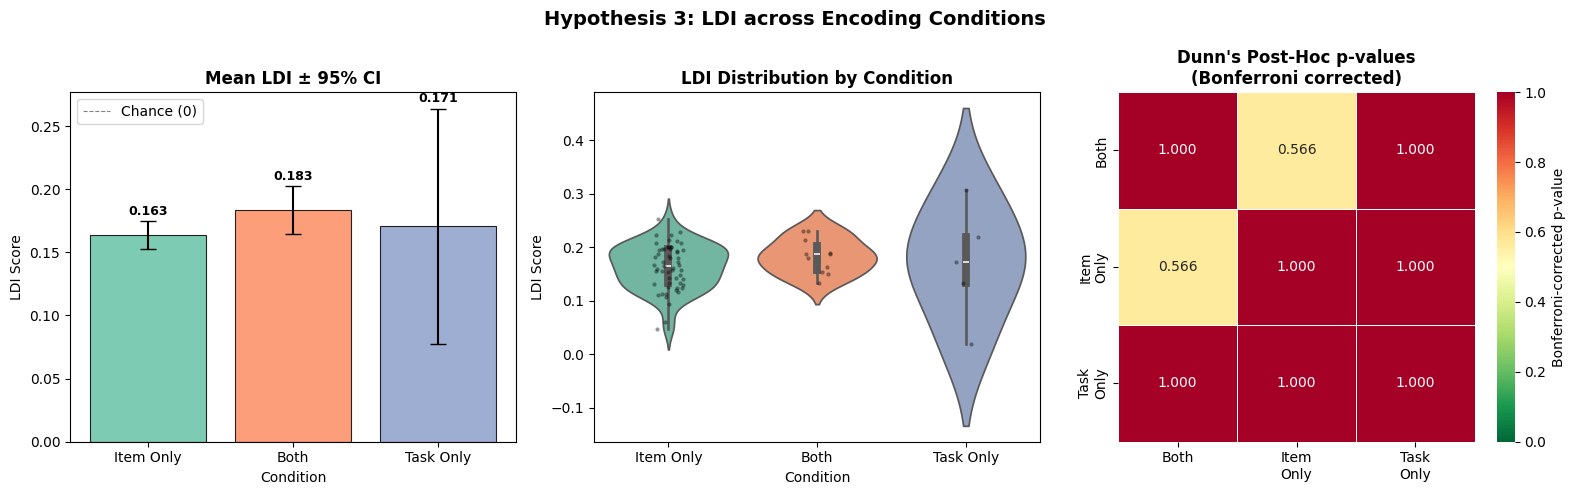

In [90]:
condition_order  = ['item_only', 'both', 'task_only']
condition_labels = ['Item Only', 'Both', 'Task Only']
palette = sns.color_palette("Set2", 3)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Hypothesis 3: LDI across Encoding Conditions", fontsize=14, fontweight='bold')

# --- Bar plot with 95% CI ---
ax = axes[0]
means = results.groupby('condition')['LDI'].mean().reindex(condition_order)
sems  = results.groupby('condition')['LDI'].sem().reindex(condition_order)
ax.bar(condition_labels, means.values, yerr=sems.values * 1.96,
       capsize=6, color=palette, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Chance (0)')
for i, (m, s) in enumerate(zip(means.values, sems.values * 1.96)):
    ax.text(i, m + s + 0.005, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Mean LDI ± 95% CI', fontweight='bold')
ax.set_ylabel('LDI Score')
ax.set_xlabel('Condition')
ax.legend()

# --- Violin + strip plot ---
ax = axes[1]
sns.violinplot(data=results, x='condition', y='LDI', order=condition_order,
               palette=palette, inner='box', ax=ax)
sns.stripplot(data=results, x='condition', y='LDI', order=condition_order,
              color='black', alpha=0.4, jitter=True, size=3, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels(condition_labels)
ax.set_title('LDI Distribution by Condition', fontweight='bold')
ax.set_ylabel('LDI Score')
ax.set_xlabel('Condition')

# --- Dunn p-value heatmap ---
ax = axes[2]
cond_short = {'item_only': 'Item\nOnly', 'both': 'Both', 'task_only': 'Task\nOnly'}
dunn_display = dunn_ldi.rename(index=cond_short, columns=cond_short)
sns.heatmap(dunn_display, annot=True, fmt='.3f', cmap='RdYlGn_r',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Bonferroni-corrected p-value'})
ax.set_title("Dunn's Post-Hoc p-values\n(Bonferroni corrected)", fontweight='bold')

plt.tight_layout()
plt.show()


### Hypothesis 3: Interpretation of LDI Results and Conclusion

**Claim:** The type of encoding task a participant performs affects their ability to discriminate lures from targets, measured by the Lure Discrimination Index (LDI).

| Term | Description |
|---|---|
| **H₀** | LDI is the same across all three encoding conditions (`item_only`, `both`, `task_only`) |
| **H₁** | At least one encoding condition produces a significantly different LDI |
| **IV** | Encoding condition — categorical, 3 levels |
| **DV** | LDI per participant — continuous |



#### Descriptive Statistics

| Condition   | Mean LDI |
|-------------|----------|
| `both`      | 0.183    |
| `task_only` | 0.171    |
| `item_only` | 0.163    |

All three group means are above zero, indicating that participants across all conditions demonstrated above-chance pattern separation ability.



#### Assumption Checks

**Normality — Shapiro-Wilk Test:**

| Condition   | W      | p-value | Result |
|-------------|--------|---------|--------|
| `item_only` | 0.9762 | 0.3323  | ✅ Normal |
| `both`      | 0.9471 | 0.6074  | ✅ Normal |
| `task_only` | 0.9929 | 0.9887  | ✅ Normal |

All three groups satisfy normality (p > 0.05). Despite this, a **Kruskal-Wallis test** was used as a robust non-parametric alternative, appropriate given the prior finding of unequal variances across conditions (Levene's test p < 0.05 for LDI).



#### Inferential Results

**Kruskal-Wallis Test:**
- H-statistic = **1.7924**, p-value = **0.4081**
- Effect size (η²) = **−0.003** ≈ negligible (< small threshold of 0.01)

The result is **not statistically significant** (p > 0.05). There is virtually no variance in LDI explained by the encoding condition.

**Dunn's Post-Hoc Test (Bonferroni corrected):**

| Pair | Corrected p |
|------|-------------|
| `both` vs `item_only` | 0.566 |
| `both` vs `task_only` | 1.000 |
| `item_only` vs `task_only` | 1.000 |

No pairwise comparison approaches significance. The observed numerical differences in group means (0.163 to 0.183) are entirely within the range expected by chance.


#### Verdict

**Fail to Reject H₀**

The encoding condition (`item_only`, `both`, `task_only`) does **not** significantly affect lure discrimination ability (LDI). The Kruskal-Wallis test yielded H = 1.79, p = 0.41, with a negligible effect size (η² ≈ 0), and all Bonferroni-corrected post-hoc comparisons were non-significant. While mean LDI values differ slightly across conditions (range: 0.163–0.183), these differences are indistinguishable from random variation. Participants show consistent above-chance pattern separation regardless of which encoding task they performed.

---

## Encoding–Retrieval Correlations using Reaction Time

This analysis explores whether the time taken to process an image during encoding predicts retrieval performance. The core idea is rooted in the levels-of-processing framework — images that required more deliberate processing during encoding (slower RT) may produce stronger, more detailed memory traces, leading to better or faster retrieval.

What we correlate:
- Encoding RT (from task CSVs): time taken per image during the shoebox task. If key_resp_9.rt is available, that is the RT. If not, total RT = 3 + key_resp_8.rt
- Retrieval RT (from test CSVs): key_resp_3.rt for the same image during the test phase

Both are matched within each participant using the image filename as the key. Note that foils are excluded automatically since they were never shown during encoding.

**Approach**:
For each participant, a Spearman correlation is computed between their encoding RT and retrieval RT across all matched images (targets and lures). This gives a per-participant correlation coefficient, which is then tested against zero using a one-sample t-test — consistent with the approach used for REC and LDI. The analysis is further broken down by encoding condition (item_only, both, task_only) to examine whether the encoding-retrieval RT relationship differs based on how participants engaged with the stimuli during encoding.

**Expected outcome**:
A negative correlation would suggest that slower, deeper encoding leads to faster retrieval — supporting levels-of-processing theory. A positive correlation would suggest that image complexity drives both slow encoding and slow retrieval. Either direction is theoretically meaningful and worth reporting.

In [91]:
# Build per-participant encoding RT lookup
# key_resp_9.rt = shoebox RT; key_resp_8.rt = indoor/outdoor RT; use whichever is present
enc_rt_df = encoding_all[['participant', 'condition', 'stim_id', 'key_resp_9.rt', 'key_resp_8.rt']].copy()
enc_rt_df['enc_rt'] = enc_rt_df['key_resp_9.rt'].combine_first(enc_rt_df['key_resp_8.rt'])
enc_rt_df = enc_rt_df.dropna(subset=['enc_rt', 'stim_id'])
enc_rt_df = enc_rt_df.drop_duplicates(subset=['participant', 'stim_id'])

# Retrieval RT from test data (foils excluded — they have no encoding match)
ret_rt_df = data[data['stim_type'].isin(['target', 'lure'])][['participant', 'condition', 'stim_id', 'stim_type', 'key_resp_3.rt']].copy()
ret_rt_df = ret_rt_df.dropna(subset=['key_resp_3.rt', 'stim_id'])

# Merge on participant x stim_id
enc_ret = ret_rt_df.merge(
    enc_rt_df[['participant', 'stim_id', 'enc_rt']],
    on=['participant', 'stim_id'],
    how='inner'
)

print(f'Matched trials: {len(enc_ret)}')
print(f'Participants:   {enc_ret["participant"].nunique()}')
print(f'Conditions:     {enc_ret["condition"].unique()}')
print(enc_ret[['participant', 'stim_id', 'stim_type', 'enc_rt', 'key_resp_3.rt']].head())

Matched trials: 19267
Participants:   72
Conditions:     ['item_only' 'both' 'task_only']
  participant  stim_id stim_type    enc_rt  key_resp_3.rt
0       00025      151      lure  0.967451       2.411447
1       00025      191    target  1.064489       2.294065
2       00025      133    target  0.707614       3.106017
3       00025      149    target  1.466033       1.983663
4       00025      144    target  0.815600       1.365811


In [92]:
from scipy.stats import spearmanr, ttest_1samp

# Compute Spearman r per participant
corr_rows = []
for pid, grp in enc_ret.groupby('participant'):
    if len(grp) < 5:
        continue
    r, p = spearmanr(grp['enc_rt'], grp['key_resp_3.rt'])
    corr_rows.append({
        'participant': pid,
        'condition':   grp['condition'].iloc[0],
        'spearman_r':  r,
        'p_value':     p,
        'n_trials':    len(grp)
    })

corr_df = pd.DataFrame(corr_rows)
print(f'Participants with valid correlations: {len(corr_df)}')
print(corr_df.groupby('condition')['spearman_r'].describe().round(3))

Participants with valid correlations: 72
           count   mean    std    min    25%    50%    75%    max
condition                                                        
both        11.0  0.000  0.088 -0.095 -0.071 -0.034  0.057  0.166
item_only   56.0 -0.004  0.066 -0.187 -0.048 -0.002  0.026  0.161
task_only    5.0 -0.015  0.082 -0.161  0.008  0.021  0.027  0.028


In [93]:
# Overall one-sample t-test: is mean Spearman r different from 0?
t_stat, p_val = ttest_1samp(corr_df['spearman_r'], 0)
mean_r = corr_df['spearman_r'].mean()
sem_r  = corr_df['spearman_r'].sem()

print('=== Overall Encoding-Retrieval RT Correlation ===')
print(f'Mean Spearman r = {mean_r:.4f}  (SEM = {sem_r:.4f})')
print(f't({len(corr_df)-1}) = {t_stat:.4f},  p = {p_val:.4f}')
print()

# Per-condition one-sample t-tests
print('=== Per-Condition One-Sample t-tests (vs r = 0) ===')
for cond, grp in corr_df.groupby('condition'):
    t, p = ttest_1samp(grp['spearman_r'], 0)
    n = len(grp)
    mr = grp['spearman_r'].mean()
    print(f'{cond:12s}  n={n:2d}  mean r={mr:+.4f}  t({n-1})={t:.4f}  p={p:.4f}')

=== Overall Encoding-Retrieval RT Correlation ===
Mean Spearman r = -0.0042  (SEM = 0.0082)
t(71) = -0.5103,  p = 0.6114

=== Per-Condition One-Sample t-tests (vs r = 0) ===
both          n=11  mean r=+0.0001  t(10)=0.0027  p=0.9979
item_only     n=56  mean r=-0.0040  t(55)=-0.4562  p=0.6501
task_only     n= 5  mean r=-0.0154  t(4)=-0.4222  p=0.6946


In [94]:
# Spearman r separately for targets and lures
print('=== Encoding-Retrieval RT Correlation by Stimulus Type ===')
stim_corr = {}
for stype in ['target', 'lure']:
    sub = enc_ret[enc_ret['stim_type'] == stype]
    rows = []
    for pid, grp in sub.groupby('participant'):
        if len(grp) < 5:
            continue
        r, _ = spearmanr(grp['enc_rt'], grp['key_resp_3.rt'])
        rows.append({'participant': pid, 'condition': grp['condition'].iloc[0], 'spearman_r': r})
    df_s = pd.DataFrame(rows)
    stim_corr[stype] = df_s
    t, p = ttest_1samp(df_s['spearman_r'], 0)
    n = len(df_s)
    mr = df_s['spearman_r'].mean()
    print(f'{stype:8s}  n={n:2d}  mean r={mr:+.4f}  t({n-1})={t:.4f}  p={p:.4f}')

=== Encoding-Retrieval RT Correlation by Stimulus Type ===
target    n=72  mean r=-0.0096  t(71)=-0.7938  p=0.4300
lure      n=72  mean r=-0.0000  t(71)=-0.0038  p=0.9970


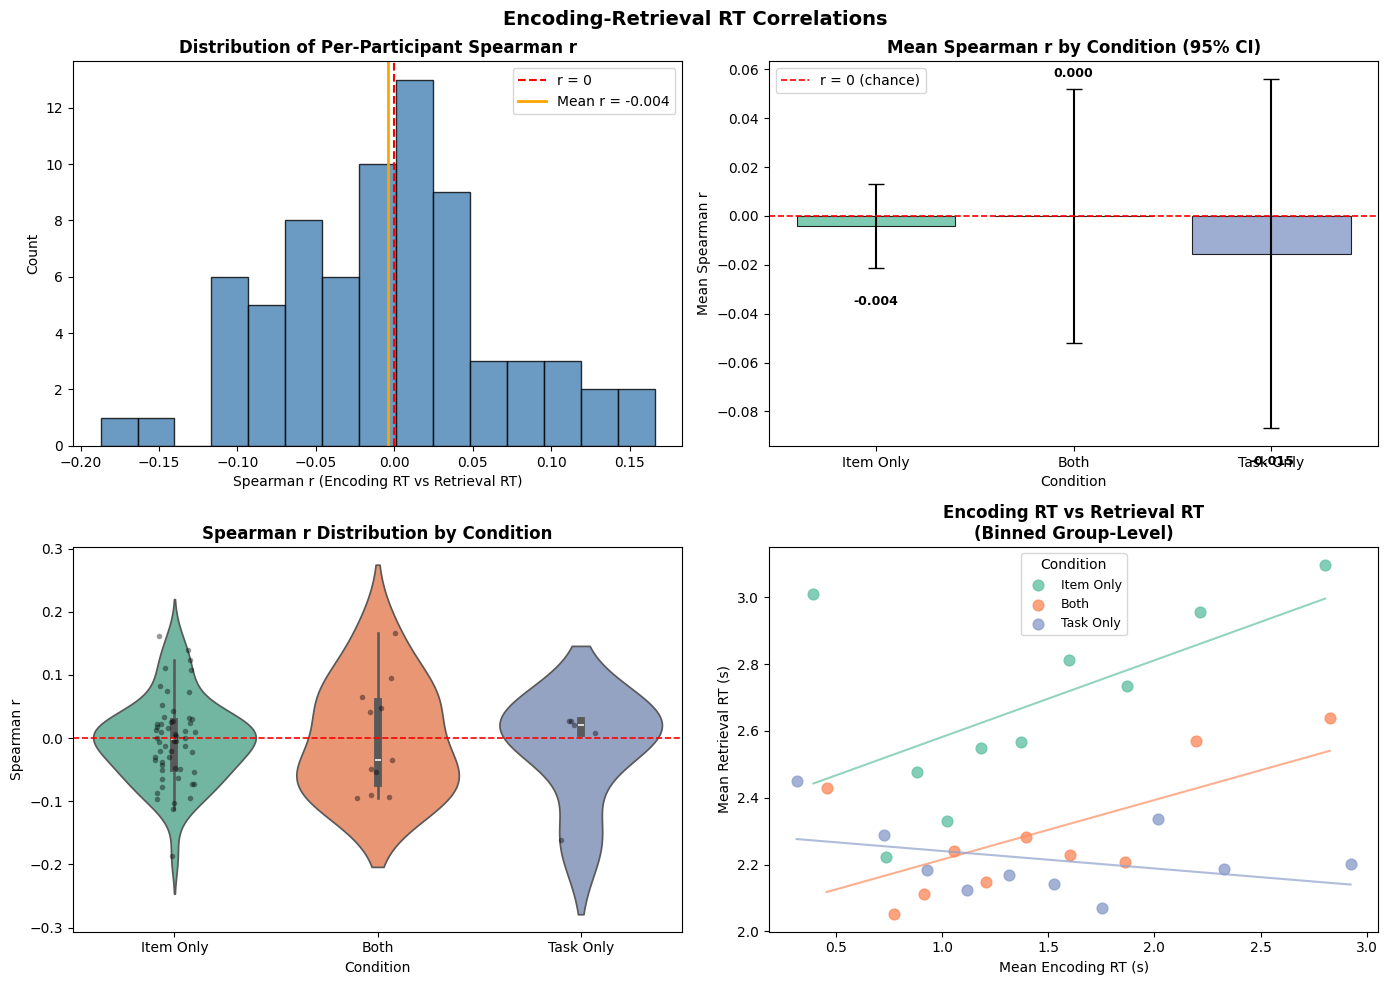

In [95]:
condition_order  = ['item_only', 'both', 'task_only']
condition_labels = ['Item Only', 'Both', 'Task Only']
palette = sns.color_palette('Set2', 3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Encoding-Retrieval RT Correlations', fontsize=14, fontweight='bold')

# Plot 1: Distribution of per-participant Spearman r
ax = axes[0, 0]
ax.hist(corr_df['spearman_r'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='r = 0')
mean_label = f"Mean r = {corr_df['spearman_r'].mean():.3f}"
ax.axvline(corr_df['spearman_r'].mean(), color='orange', linestyle='-', linewidth=2, label=mean_label)
ax.set_title('Distribution of Per-Participant Spearman r', fontweight='bold')
ax.set_xlabel('Spearman r (Encoding RT vs Retrieval RT)')
ax.set_ylabel('Count')
ax.legend()

# Plot 2: Mean Spearman r by condition with 95% CI
ax = axes[0, 1]
means = corr_df.groupby('condition')['spearman_r'].mean().reindex(condition_order)
sems  = corr_df.groupby('condition')['spearman_r'].sem().reindex(condition_order)
ax.bar(condition_labels, means.values, yerr=sems.values * 1.96,
       capsize=6, color=palette, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='r = 0 (chance)')
for i, (m, s) in enumerate(zip(means.values, sems.values * 1.96)):
    offset = s + 0.005 if m >= 0 else -(s + 0.015)
    ax.text(i, m + offset, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Mean Spearman r by Condition (95% CI)', fontweight='bold')
ax.set_ylabel('Mean Spearman r')
ax.set_xlabel('Condition')
ax.legend()

# Plot 3: Violin + strip plot of Spearman r by condition
ax = axes[1, 0]
sns.violinplot(data=corr_df, x='condition', y='spearman_r',
               order=condition_order, palette=palette, inner='box', ax=ax)
sns.stripplot(data=corr_df, x='condition', y='spearman_r',
              order=condition_order, color='black', alpha=0.4, jitter=True, size=4, ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax.set_xticklabels(condition_labels)
ax.set_title('Spearman r Distribution by Condition', fontweight='bold')
ax.set_ylabel('Spearman r')
ax.set_xlabel('Condition')

# Plot 4: Binned group-level encoding RT vs retrieval RT scatter
ax = axes[1, 1]
for i, cond in enumerate(condition_order):
    sub = enc_ret[enc_ret['condition'] == cond].copy()
    sub['enc_rt_bin'] = pd.qcut(sub['enc_rt'], q=10, duplicates='drop')
    binned = sub.groupby('enc_rt_bin', observed=True)[['enc_rt', 'key_resp_3.rt']].mean()
    ax.scatter(binned['enc_rt'], binned['key_resp_3.rt'],
               label=condition_labels[i], color=palette[i], s=60, alpha=0.8)
    z = np.polyfit(binned['enc_rt'], binned['key_resp_3.rt'], 1)
    xline = np.linspace(binned['enc_rt'].min(), binned['enc_rt'].max(), 100)
    ax.plot(xline, np.polyval(z, xline), color=palette[i], linewidth=1.5, alpha=0.7)
ax.set_title('Encoding RT vs Retrieval RT\n(Binned Group-Level)', fontweight='bold')
ax.set_xlabel('Mean Encoding RT (s)')
ax.set_ylabel('Mean Retrieval RT (s)')
ax.legend(title='Condition', fontsize=9)

plt.tight_layout()
plt.show()

### Encoding–Retrieval RT Correlations: Results and Interpretation

---

#### Overview

This analysis tested whether the time taken to process an image during encoding predicted how quickly (and reliably) participants responded to that same image at retrieval. A per-participant Spearman correlation was computed between encoding RT and retrieval RT across all matched trials (targets and lures). The resulting distribution of correlation coefficients was then tested against zero using a one-sample t-test, consistent with the approach used for REC and LDI throughout this study.

19,267 trials were successfully matched across encoding and test phases for **72 participants** spanning all three conditions.

---

#### Descriptive Statistics

| Condition | n | Mean Spearman r | SD |
|-----------|---|-----------------|----|
| `both` | 11 | +0.000 | 0.088 |
| `item_only` | 56 | −0.004 | 0.066 |
| `task_only` | 5 | −0.015 | 0.082 |
| **Overall** | **72** | **−0.004** | **0.070** |

All mean correlations are extremely close to zero, with distributions centered near r = 0 regardless of condition. The interquartile ranges (25th–75th percentile) span roughly −0.05 to +0.03, confirming that most participants show negligible encoding–retrieval RT coupling.

---

#### Inferential Results

**Overall one-sample t-test (vs r = 0):**

| Statistic | Value |
|-----------|-------|
| Mean Spearman r | −0.0042 |
| SEM | 0.0082 |
| t(71) | −0.5103 |
| p-value | 0.6114 |

The mean correlation across all participants is not significantly different from zero (p = 0.61). The effect is negligible.

**Per-condition one-sample t-tests:**

| Condition | n | Mean r | t | p |
|-----------|---|--------|---|---|
| `both` | 11 | +0.0001 | t(10) = 0.003 | 0.998 |
| `item_only` | 56 | −0.0040 | t(55) = −0.456 | 0.650 |
| `task_only` | 5 | −0.0154 | t(4) = −0.422 | 0.695 |

No condition shows a significant encoding–retrieval RT correlation. All p-values are well above 0.05, and the effect sizes are trivially small.

**By stimulus type:**

| Stimulus Type | n | Mean r | t | p |
|---------------|---|--------|---|---|
| Targets | 72 | −0.0096 | t(71) = −0.794 | 0.430 |
| Lures | 72 | −0.0000 | t(71) = −0.004 | 0.997 |

Neither targets nor lures show any reliable encoding–retrieval RT coupling. The near-zero correlation for lures is particularly striking — how long participants looked at the original image during encoding had essentially no relationship with their response time to the lure at test.

---

#### Interpretation

**No meaningful encoding–retrieval RT correlation was found.**

The levels-of-processing account would predict a negative correlation — items that demanded slower, more deliberate encoding should yield faster or more confident retrieval. The transfer-appropriate processing view would predict a positive correlation — images that were intrinsically complex or difficult to categorise would slow both encoding and retrieval. Neither prediction is supported here.

Several explanations are possible:

1. **RT reflects task demands, not memory encoding depth.** Encoding RT in this paradigm is largely driven by the response key deadline and individual motor speed, not by how deeply the image was processed. Items that participants studied carefully and items they responded to reflexively both appear at the same average encoding RT.

2. **Retrieval RT is influenced by recognition confidence, not encoding duration.** At test, RT reflects the speed of a familiarity/recollection judgment. This is governed by the clarity of the memory trace (strong vs. weak), not directly by how long the image was viewed during study.

3. **Between-participant variance dominates within-participant trial-level variance.** The per-participant Spearman approach removes between-participant differences; the remaining within-participant variance in encoding RT may simply be too noisy to correlate with retrieval RT across ~250 matched trials per participant.

---

#### Conclusion

Encoding reaction time does not predict retrieval reaction time in this MST paradigm. The mean Spearman r across 72 participants is −0.004 (t(71) = −0.51, p = 0.61), indistinguishable from zero. This null result holds across all three encoding conditions (`item_only`, `both`, `task_only`) and for both targets and lures individually. Reaction time at encoding is therefore not a useful proxy for encoding depth or subsequent memory strength in this task design.